# Verification-01: Engagement Model Training

Train and evaluate session-level engagement models (XGBoost and EBM) with clear metrics, plots, and report artifacts.


In [1]:
# Core Python utilities.
import warnings, os, json, random, sys
from datetime import datetime, timezone
from pathlib import Path
warnings.filterwarnings("ignore")

# Data and plotting libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluation metrics and plotting helpers.
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.calibration import CalibrationDisplay
from sklearn.model_selection import StratifiedGroupKFold

# Model libraries (from requirements.txt).
import xgboost as xgb
from interpret.glassbox import ExplainableBoostingClassifier
import shap
import joblib

print(f"XGBoost {xgb.__version__}")
print(f"SHAP {shap.__version__}")

# Resolve the project root, then import shared feature/preprocessing code.
PROJECT_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "verification").exists() and (candidate / "requirements.txt").exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise RuntimeError("Could not locate the project root for imports.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)
print(f"Project root: {PROJECT_ROOT}")

from verification.engagement.common.preprocessing import (
    fit_numeric_preprocessing,
    save_preprocessing_artifact,
    select_numeric_feature_frame,
    transform_numeric_frame,
)
from verification.engagement.common.event_pipeline import clean_raw_events, build_features

# Reproducibility.
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Plot style.
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120

# Paths.
DATA_DIR = str(PROJECT_ROOT / "data")
LABELED_DATA_PATH = os.path.join(DATA_DIR, "sessions_features_labeled.csv")
XGBOOST_ARTIFACTS = str(PROJECT_ROOT / "verification/engagement/xgboost/artifacts")
EBM_ARTIFACTS = str(PROJECT_ROOT / "verification/engagement/ebm/artifacts")
XGBOOST_REPORT_DIR = str(PROJECT_ROOT / "reports/xgboost")
EBM_REPORT_DIR = str(PROJECT_ROOT / "reports/ebm")
ENGAGEMENT_REPORT_DIR = str(PROJECT_ROOT / "reports/engagement")

for d in [DATA_DIR, XGBOOST_ARTIFACTS, EBM_ARTIFACTS, XGBOOST_REPORT_DIR, EBM_REPORT_DIR, ENGAGEMENT_REPORT_DIR]:
    os.makedirs(d, exist_ok=True)

# Display settings.
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 30)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

# Training and evaluation config.
N_RANDOM_TRIALS = 40
# Used only for evaluation views and report tables in this file.
# Final pass/fail threshold can be decided by backend independently.
ENGAGEMENT_THRESHOLD = 0.85

print()
print("Setup complete.")


XGBoost 3.2.0
SHAP 0.51.0
Project root: e:\IIT\YEAR 05\SEMISTER 01\FYP\certifytube_ml_model

Setup complete.


---
## Step 01 - Load Raw Event Data


In [2]:
# Load raw event logs from the dataset folder.
raw_path = os.path.join(DATA_DIR, "events_raw.csv")
df_raw = pd.read_csv(raw_path)
print(f"Loaded raw events: {raw_path}")
print(f"Shape: {df_raw.shape}")
df_raw.head()


Loaded raw events: e:\IIT\YEAR 05\SEMISTER 01\FYP\certifytube_ml_model\data\events_raw.csv
Shape: (10, 15)


,event_id,session_id,user_id,video_id,video_title,event_type,player_state,playback_rate,current_time_sec,video_duration_sec,created_at_utc,client_created_at_local,client_tz_offset_min,seek_from_sec,seek_to_sec
0,99f00b99-3a77-4524-ac9f-d61059ab61fe,13681926-25ed-4084-b949-af11f6e36c66,user_001,pTB0EiLXUC8,"Object-Oriented Programming, Simplified",ready,5,1.0000,0.0000,454.0000,2026-03-26T00:17:55.850106,2026-03-26T00:17:49.681Z,330,NaN,NaN
1,4b4b062c-b52d-48b1-aeee-15d21b8ac5a1,13681926-25ed-4084-b949-af11f6e36c66,user_001,pTB0EiLXUC8,"Object-Oriented Programming, Simplified",buffering,3,1.0000,0.0000,454.0000,2026-03-26T00:17:55.887156,2026-03-26T00:17:52.332Z,330,NaN,NaN
2,d81f2b76-d35b-4d9a-9764-fb47d6b366a6,13681926-25ed-4084-b949-af11f6e36c66,user_001,pTB0EiLXUC8,"Object-Oriented Programming, Simplified",play,1,1.0000,0.0192,453.9010,2026-03-26T00:17:55.886954,2026-03-26T00:17:53.215Z,330,NaN,NaN
3,0763e3f2-ab2c-4dde-b361-c2cb7d2932a8,13681926-25ed-4084-b949-af11f6e36c66,user_001,pTB0EiLXUC8,"Object-Oriented Programming, Simplified",pause,2,1.0000,155.2438,454.0000,2026-03-26T00:20:28.795194,2026-03-26T00:20:28.469Z,330,NaN,NaN
4,66eaf479-b02e-49c7-a27e-ff0f94221a12,13681926-25ed-4084-b949-af11f6e36c66,user_001,pTB0EiLXUC8,"Object-Oriented Programming, Simplified",buffering,3,1.0000,155.3075,454.0000,2026-03-26T00:20:29.196660,2026-03-26T00:20:29.193Z,330,NaN,NaN


In [3]:
# Quick inspection of data types and null counts after load.
print("=== Data Types ===")
print(df_raw.dtypes)
print()
missing_counts = df_raw.isna().sum().sort_values(ascending=False)
print("=== Missing Values (top) ===")
print(missing_counts.head(20))
print()
seek_event_count = int(df_raw["event_type"].fillna("").astype(str).str.strip().str.lower().eq("seek").sum())
seek_payload_rows = int(df_raw[["seek_from_sec", "seek_to_sec"]].notna().all(axis=1).sum())
print(f"Seek events in raw file: {seek_event_count}")
print(f"Rows with both seek_from_sec and seek_to_sec populated: {seek_payload_rows}")
if seek_event_count == 0 and seek_payload_rows == 0:
    print("Note: this sample CSV has no seek rows, so missing seek_from_sec/seek_to_sec values are expected here.")


=== Data Types ===
event_id                       str
session_id                     str
user_id                        str
video_id                       str
video_title                    str
event_type                     str
player_state                 int64
playback_rate              float64
current_time_sec           float64
video_duration_sec         float64
created_at_utc                 str
client_created_at_local        str
client_tz_offset_min         int64
seek_from_sec              float64
seek_to_sec                float64
dtype: object

=== Missing Values (top) ===
seek_from_sec              10
seek_to_sec                10
event_id                    0
video_id                    0
video_title                 0
session_id                  0
user_id                     0
player_state                0
event_type                  0
playback_rate               0
current_time_sec            0
created_at_utc              0
video_duration_sec          0
client_tz_offset_min  

---
## Step 02 - Clean Event Data

Apply timestamp fixes, numeric coercion, de-duplication, and outlier clipping before feature engineering.


In [4]:
# 2.1-2.8 - Reusable raw-event cleaning pipeline
# This is the same cleanup logic the live API now uses for backend event payloads.
df_raw_before_clean = df_raw.copy()
df_raw = clean_raw_events(df_raw)

print(f"Cleaned dataset: {df_raw.shape}")
print(f"Rows removed during cleaning: {len(df_raw_before_clean) - len(df_raw)}")

dtype_changes = pd.DataFrame({
    "before": df_raw_before_clean.dtypes.astype(str),
    "after": df_raw.dtypes.astype(str),
})
dtype_changes = dtype_changes[dtype_changes["before"] != dtype_changes["after"]]
if len(dtype_changes) > 0:
    print("\n=== Dtype Changes During Cleaning ===")
    print(dtype_changes)
else:
    print("\nNo dtype changes during cleaning.")


Cleaned dataset: (10, 15)
Dtypes after cleaning:
event_id                                   str
session_id                                 str
user_id                                    str
video_id                                   str
video_title                                str
event_type                                 str
player_state                             Int64
playback_rate                          float64
current_time_sec                       float64
video_duration_sec                     float64
created_at_utc             datetime64[us, UTC]
client_created_at_local    datetime64[us, UTC]
client_tz_offset_min                     int64
seek_from_sec                          float64
seek_to_sec                            float64
dtype: object


In [5]:
print("Shared cleaning function applied from verification.engagement.common.event_pipeline")
print(f"Rows after cleaning: {len(df_raw)}")
print(f"Sessions after cleaning: {df_raw['session_id'].nunique()}")
print(f"Users after cleaning: {df_raw['user_id'].nunique()}")
print()
event_order = ["ready", "play", "pause", "buffering", "seek", "ratechange", "ended"]
event_counts = df_raw["event_type"].value_counts().reindex(event_order, fill_value=0)
print("Event counts after cleaning:")
print(event_counts)
print()
seek_event_count = int(event_counts["seek"])
seek_payload_rows = int(df_raw[["seek_from_sec", "seek_to_sec"]].notna().all(axis=1).sum())
print(f"Seek events after cleaning: {seek_event_count}")
print(f"Rows with seek_from_sec and seek_to_sec after cleaning: {seek_payload_rows}")


Shared cleaning function applied from verification.engagement.common.event_pipeline
Rows after cleaning: 10
Sessions after cleaning: 1
Users after cleaning: 1


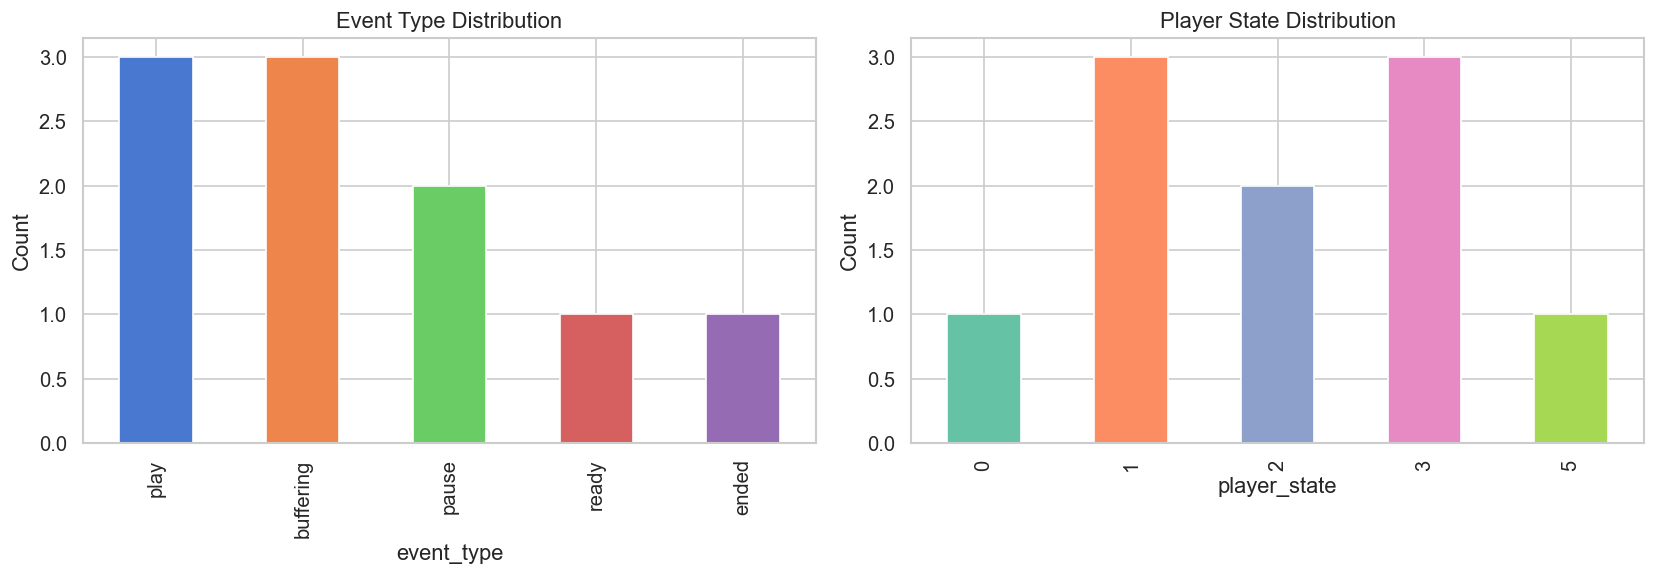

Player states: 0=ended, 1=playing, 2=paused, 3=buffering, 5=cued/ready


In [6]:
# Event & player state distributions
event_order = ["ready", "play", "pause", "buffering", "seek", "ratechange", "ended"]
event_counts = df_raw["event_type"].value_counts().reindex(event_order, fill_value=0)
player_state_order = [0, 1, 2, 3, 5]
player_state_counts = df_raw["player_state"].value_counts().reindex(player_state_order, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
event_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette("muted", n_colors=len(event_counts)))
axes[0].set_title("Event Type Distribution")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)
player_state_counts.plot(kind='bar', ax=axes[1], color=sns.color_palette("Set2", n_colors=len(player_state_counts)))
axes[1].set_title("Player State Distribution")
axes[1].set_ylabel("Count")
plt.tight_layout(); plt.show()
print("Player states: 0=ended, 1=playing, 2=paused, 3=buffering, 5=cued/ready")
print(f"Seek count shown above: {int(event_counts['seek'])} (0 means this sample CSV simply has no seek rows).")

---
## Step 03 - Column Guide

| Column | Description |
|---|---|
| `event_type` | Event kind: `ready`, `play`, `pause`, `buffering`, `ended`, `seek`, `ratechange` |
| `player_state` | 0=ended, 1=playing, 2=paused, 3=buffering, 5=ready/cued |
| `playback_rate` | Current speed (e.g., 0.75, 1.0, 1.25) |
| `current_time_sec` | Current playback position in seconds |
| `video_duration_sec` | Total video length in seconds |
| `created_at_utc` | Canonical event timestamp used for ordering and feature timing |
| `client_created_at_local` | Client-side local timestamp before UTC normalization |
| `client_tz_offset_min` | Client timezone offset in minutes |
| `seek_from_sec` | Seek start position. Usually null except on seek rows. |
| `seek_to_sec` | Seek target position. Usually null except on seek rows. |


---
## Step 04 - Canonical 49-Feature List


---
## Step 05 - Build Session Features


In [7]:
# build_features() lives in event_pipeline.py so training and inference reuse
# one implementation instead of keeping two copies in sync.
print("build_features() imported from verification.engagement.common.event_pipeline")


build_features() imported from verification.engagement.common.event_pipeline


In [8]:
# Many raw event rows become one session-level row here.
# META_COLS are identifiers only; FEATURE_COLS are the numeric model inputs.
df_features = build_features(df_raw)
META_COLS = ['session_id','user_id','video_id','video_title']
FEATURE_COLS = [c for c in df_features.columns if c not in META_COLS + ['engagement_label']]
print(f"Shape: {df_features.shape}  |  Features: {len(FEATURE_COLS)}")
df_features.head()

Shape: (1, 54)  |  Features: 49


,session_id,user_id,video_id,video_title,session_duration_sec,video_duration_sec,last_position_sec,completed_flag,watch_time_sec,watch_time_ratio,completion_ratio,engagement_velocity,num_pause,total_pause_duration_sec,avg_pause_duration_sec,median_pause_duration_sec,pause_freq_per_min,long_pause_count,long_pause_ratio,num_seek,num_seek_forward,num_seek_backward,total_seek_forward_sec,total_seek_backward_sec,avg_seek_forward_sec,avg_seek_backward_sec,largest_forward_seek_sec,largest_backward_seek_sec,seek_jump_std_sec,seek_forward_ratio,seek_backward_ratio,skip_time_ratio,rewatch_time_ratio,rewatch_to_skip_ratio,seek_density_per_min,first_seek_time_sec,early_skip_flag,num_ratechange,time_at_speed_lt1x_sec,time_at_speed_1x_sec,time_at_speed_gt1x_sec,fast_ratio,slow_ratio,playback_speed_variance,avg_playback_rate_when_playing,unique_speed_levels,num_buffering_events,buffering_time_sec,buffering_freq_per_min,play_pause_ratio,attention_index,skim_flag,deep_flag,engagement_label
0,13681926-25ed-4084-b949-af11f6e36c66,user_001,pTB0EiLXUC8,"Object-Oriented Programming, Simplified",455.7749,454.0000,453.9010,1,298.4605,0.6548,0.9998,0.6548,2,3.8122,1.9061,1.9061,0.2633,0,0.0000,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,0,0.0000,298.4605,0.0000,0.0000,0.0000,0.0000,1.0000,1,3,153.4654,0.3949,0.9874,0.6547,0,0,NaN


---
## Step 06 - Save Engineered Feature Table


In [9]:
# Save engineered session-level features before manual labeling.
feat_path = os.path.join(DATA_DIR, "sessions_features.csv")
df_features.to_csv(feat_path, index=False)
print(f"Saved engineered features to: {feat_path}")
print(f"Rows: {len(df_features)}  |  Cols: {df_features.shape[1]}")


Saved engineered features to: e:\IIT\YEAR 05\SEMISTER 01\FYP\certifytube_ml_model\data\sessions_features.csv
Rows: 1  |  Cols: 54


---
## Step 07 - Add Manual Labels

1. Open `data/sessions_features.csv`
2. Fill `engagement_label`: **1**=engaged, **0**=not engaged
3. Save as `data/sessions_features_labeled.csv`


In [10]:
# Optional heuristic auto-labeler example (disabled).
# Keep manual labels as the source of truth for training.
# df_features['engagement_label'] = (df_features['attention_index'] > 0.35).astype(int)
# df_features.to_csv(os.path.join(DATA_DIR, "sessions_features_labeled.csv"), index=False)
print("Label your data, then continue to Step 08.")


Label your data, then continue to Step 08.


---
## Step 08 - Load Labeled Data


In [11]:
# Load manually labeled sessions and auto-detect whether the CSV header starts on row 1 or row 2.
labeled_path = LABELED_DATA_PATH
required_columns = ["session_id", "user_id", "engagement_label"]

csv_path = Path(labeled_path)
last_columns = []
for header_row in (0, 1):
    df_candidate = pd.read_csv(csv_path, header=header_row)
    last_columns = list(df_candidate.columns)
    if all(col in df_candidate.columns for col in required_columns):
        df_labeled = df_candidate
        break
else:
    raise ValueError(
        f"Could not load required columns {required_columns} from {csv_path}. "
        f"Last detected columns were: {last_columns}"
    )

df_labeled["engagement_label"] = pd.to_numeric(df_labeled["engagement_label"], errors="coerce")
df_labeled = df_labeled.dropna(subset=["engagement_label"]).copy()
df_labeled["engagement_label"] = df_labeled["engagement_label"].astype(int)
df_labeled["session_id"] = df_labeled["session_id"].astype(str)
df_labeled["user_id"] = df_labeled["user_id"].astype(str)

print(f"Loaded labeled dataset: {labeled_path}")
print(f"Shape: {df_labeled.shape}")
print(f"Sessions: {df_labeled['session_id'].nunique()}")
print(f"Users:    {df_labeled['user_id'].nunique()}")
print()
print("=== Label Distribution ===")
print(df_labeled["engagement_label"].value_counts().sort_index())
print(f"Positive rate: {df_labeled['engagement_label'].mean():.4f}")


Loaded labeled dataset: e:\IIT\YEAR 05\SEMISTER 01\FYP\certifytube_ml_model\data\sessions_features_labeled.csv
Shape: (999, 54)
Sessions: 999
Users:    571

=== Label Distribution ===
engagement_label
0    512
1    487
Name: count, dtype: int64
Positive rate: 0.4875


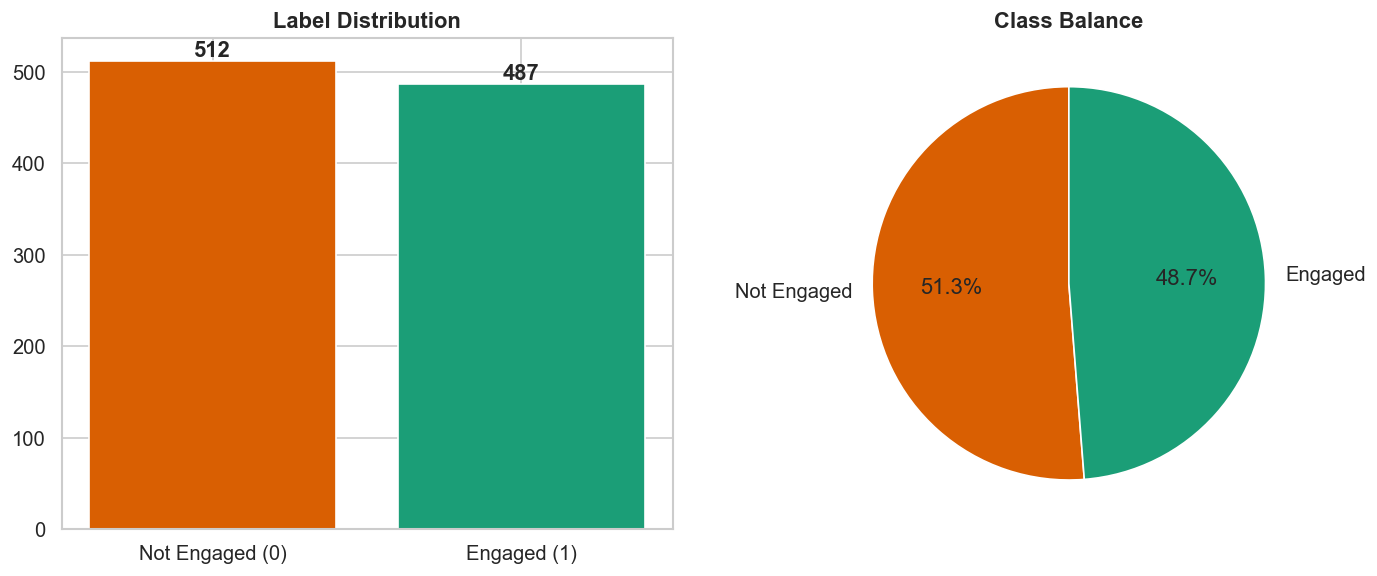

In [12]:
# Label distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
counts = df_labeled['engagement_label'].value_counts().sort_index()
bars = axes[0].bar(['Not Engaged (0)', 'Engaged (1)'], [counts.get(0,0), counts.get(1,0)],
                    color=['#d95f02','#1b9e77'], edgecolor='white')
for b, v in zip(bars, [counts.get(0,0), counts.get(1,0)]):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+5, str(v), ha='center', fontweight='bold')
axes[0].set_title("Label Distribution", fontweight='bold')
axes[1].pie([counts.get(0,0), counts.get(1,0)], labels=['Not Engaged','Engaged'],
            colors=['#d95f02','#1b9e77'], autopct='%1.1f%%', startangle=90)
axes[1].set_title("Class Balance", fontweight='bold')
plt.tight_layout(); plt.show()

---
## Step 09 - Prepare Training Inputs and Split


In [13]:
# Prepare the final training table:
# - FEATURE_COLS: numeric inputs sent into the models
# - LABEL_COL: manual engagement target
# - GROUP_COL: user_id for grouped splitting and grouped CV
META_COLS = ["session_id", "user_id", "video_id", "video_title"]
LABEL_COL = "engagement_label"
GROUP_COL = "user_id"
DROP_COLS = [LABEL_COL, GROUP_COL, "session_id", "video_id", "video_title"]

feature_df = select_numeric_feature_frame(df_labeled, drop_cols=DROP_COLS)
FEATURE_COLS = list(feature_df.columns)

clean_df = feature_df.copy()
clean_df[LABEL_COL] = df_labeled[LABEL_COL].astype(int).values
clean_df[GROUP_COL] = df_labeled[GROUP_COL].astype(str).values
clean_df["session_id"] = df_labeled["session_id"].astype(str).values

X = clean_df[FEATURE_COLS].copy()
y = clean_df[LABEL_COL].copy()

print(f"Feature columns ({len(FEATURE_COLS)})")
print(f"Rows: {len(clean_df)} | Users: {clean_df[GROUP_COL].nunique()}")

missing_pct = feature_df.isnull().mean().sort_values(ascending=False)
has_missing = missing_pct[missing_pct > 0]
if len(has_missing) > 0:
    print(f"Features with missing: {len(has_missing)}")
    fig, ax = plt.subplots(figsize=(10, max(4, len(has_missing) * 0.4)))
    has_missing.sort_values(ascending=True).plot(kind="barh", ax=ax, color="#7570b3")
    ax.set_xlabel("Missing %")
    ax.set_title("Missing Values Before Train-Only Imputation")
    plt.tight_layout()
    plt.show()
else:
    print("? No missing values before train-only preprocessing fit.")

Feature columns (49)
Rows: 999 | Users: 571
? No missing values before train-only preprocessing fit.


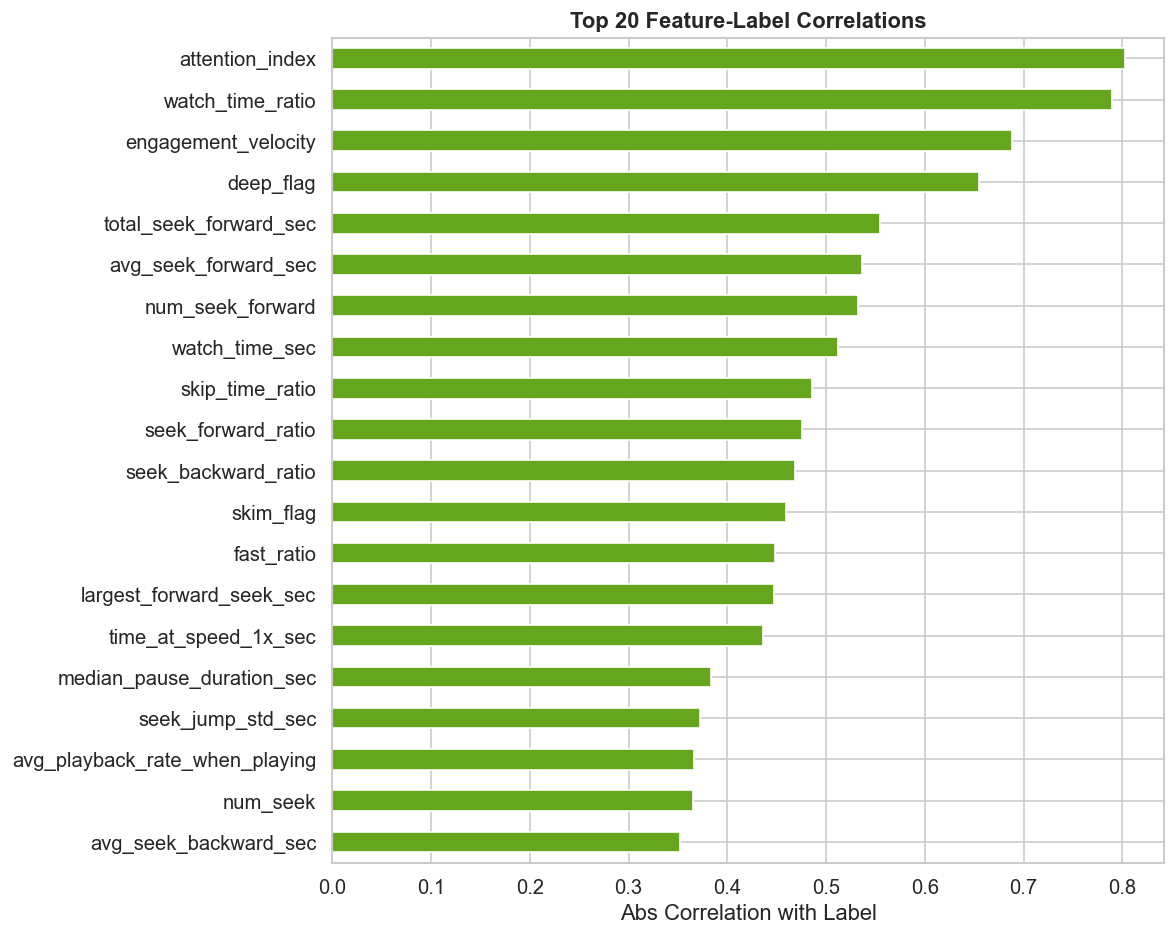

In [14]:
# Feature-label correlation (top 20 absolute values).
non_const = [c for c in FEATURE_COLS if X[c].nunique() > 1]
corr = X[non_const].corrwith(y).dropna().abs().sort_values(ascending=False).head(20)
fig, ax = plt.subplots(figsize=(10, 8))
corr.sort_values(ascending=True).plot(kind='barh', ax=ax, color='#66a61e')
ax.set_xlabel("Abs Correlation with Label")
ax.set_title("Top 20 Feature-Label Correlations", fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(ENGAGEMENT_REPORT_DIR, "feature_label_correlation_top20.png"), dpi=150, bbox_inches="tight")
plt.show()


Train: 798 rows | 458 users | 48.75% positive
Test:  201 rows | 113 users | 48.76% positive
User overlap between train/test: 0


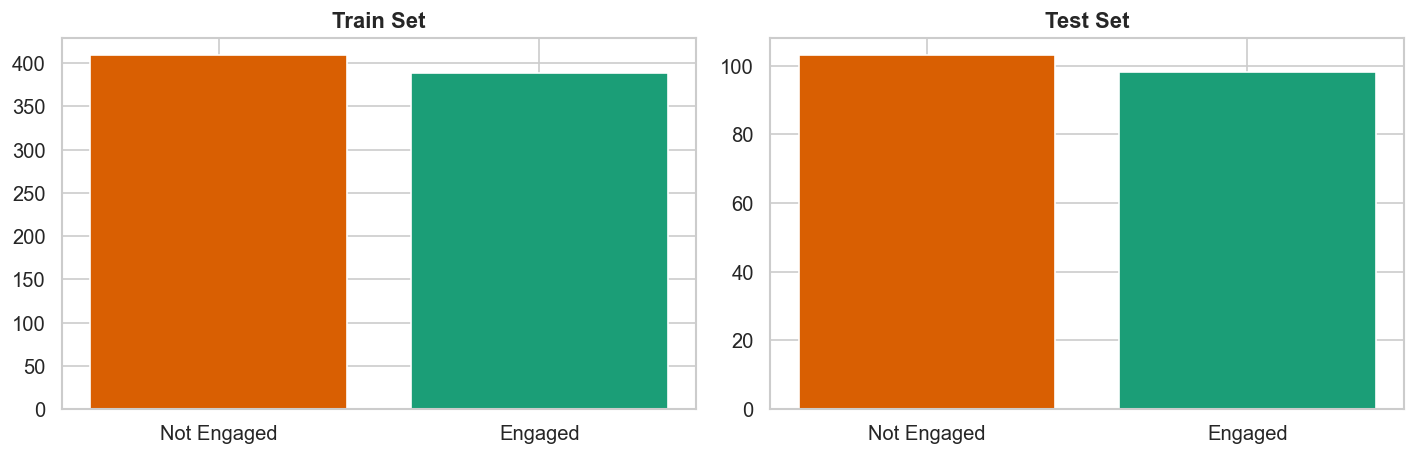

In [15]:
# Split into train/test with grouped stratification by user_id.
# This prevents the same user from appearing in both sets.
if LABEL_COL not in clean_df.columns:
    raise ValueError(f"Label column '{LABEL_COL}' not found.")
if GROUP_COL not in clean_df.columns:
    raise ValueError(f"Group column '{GROUP_COL}' not found.")

test_size = 0.2
n_splits = int(round(1.0 / test_size))
if abs((1.0 / n_splits) - test_size) > 1e-6:
    raise ValueError(f"test_size={test_size} is not supported cleanly; use values like 0.2, 0.25, 0.1")

sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
x_dummy = clean_df.drop(columns=[LABEL_COL])
y_full = clean_df[LABEL_COL].astype(int)
groups_full = clean_df[GROUP_COL].astype(str)
train_idx, test_idx = next(sgkf.split(x_dummy, y_full, groups_full))

train_df = clean_df.iloc[train_idx].reset_index(drop=True)
test_df = clean_df.iloc[test_idx].reset_index(drop=True)

eval_preprocessing = fit_numeric_preprocessing(train_df[FEATURE_COLS])
X_train = transform_numeric_frame(train_df[FEATURE_COLS], eval_preprocessing)
X_test = transform_numeric_frame(test_df[FEATURE_COLS], eval_preprocessing)
y_train = train_df[LABEL_COL].astype(int)
y_test = test_df[LABEL_COL].astype(int)

train_session_ids = train_df["session_id"].astype(str).tolist()
test_session_ids = test_df["session_id"].astype(str).tolist()
user_overlap = len(set(train_df[GROUP_COL]) & set(test_df[GROUP_COL]))

print(f"Train: {len(train_df)} rows | {train_df[GROUP_COL].nunique()} users | {y_train.mean():.2%} positive")
print(f"Test:  {len(test_df)} rows | {test_df[GROUP_COL].nunique()} users | {y_test.mean():.2%} positive")
print(f"User overlap between train/test: {user_overlap}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, ys) in zip(axes, [("Train", y_train), ("Test", y_test)]):
    vc = ys.value_counts().sort_index()
    ax.bar(["Not Engaged", "Engaged"], [vc.get(0, 0), vc.get(1, 0)], color=["#d95f02", "#1b9e77"])
    ax.set_title(f"{name} Set", fontweight="bold")
plt.tight_layout(); plt.show()


---
## Model A - XGBoost

Train and evaluate XGBoost with grouped CV random search and held-out testing.


In [16]:
# Helper functions for the next XGBoost tuning/evaluation cell.
# Keep them here because only the XGBoost training block below uses them.

def sample_xgb_params(rng: np.random.Generator) -> dict[str, object]:
    """Sample one random hyperparameter set for the XGBoost search loop."""
    return {
        "objective": "binary:logistic",
        "eval_metric": ["auc", "logloss"],
        "tree_method": "hist",
        "seed": SEED,
        "max_depth": int(rng.integers(3, 8)),
        "min_child_weight": float(rng.uniform(1, 10)),
        "eta": float(rng.uniform(0.01, 0.2)),
        "subsample": float(rng.uniform(0.6, 1.0)),
        "colsample_bytree": float(rng.uniform(0.6, 1.0)),
        "gamma": float(rng.uniform(0.0, 5.0)),
        "lambda": float(rng.uniform(0.1, 10.0)),
        "alpha": float(rng.uniform(0.0, 5.0)),
    }

def make_xgb_cv_folds(df_train: pd.DataFrame, feature_columns: list[str]) -> list[tuple[np.ndarray, np.ndarray]]:
    """Build grouped CV folds so the same user_id does not leak across folds."""
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
    y = df_train["engagement_label"].astype(int).values
    groups = df_train["user_id"].astype(str).values
    x_dummy = df_train[feature_columns].values

    folds: list[tuple[np.ndarray, np.ndarray]] = []
    for tr_idx, va_idx in sgkf.split(x_dummy, y, groups):
        folds.append((tr_idx, va_idx))
    return folds

def _train_xgb_fold(
    train_frame: pd.DataFrame,
    val_frame: pd.DataFrame,
    feature_columns: list[str],
    params: dict[str, object],
) -> dict[str, float]:
    """Train one CV fold with train-only preprocessing and early stopping."""
    fold_preprocessing = fit_numeric_preprocessing(train_frame[feature_columns])
    x_train = transform_numeric_frame(train_frame[feature_columns], fold_preprocessing).values
    x_val = transform_numeric_frame(val_frame[feature_columns], fold_preprocessing).values
    y_train = train_frame["engagement_label"].astype(int).values
    y_val = val_frame["engagement_label"].astype(int).values

    dtrain_fold = xgb.DMatrix(x_train, label=y_train, feature_names=feature_columns)
    dval_fold = xgb.DMatrix(x_val, label=y_val, feature_names=feature_columns)

    booster = xgb.train(
        params={**params, "eval_metric": "auc"},
        dtrain=dtrain_fold,
        num_boost_round=5000,
        evals=[(dval_fold, "val")],
        early_stopping_rounds=50,
        verbose_eval=False,
    )

    return {
        "best_round": int(getattr(booster, "best_iteration", 0)) + 1,
        "best_auc": float(getattr(booster, "best_score", 0.0)),
    }

def compute_xgb_metrics(y_true: np.ndarray, y_prob: np.ndarray) -> dict[str, object]:
    """Compute the held-out evaluation metrics used in reports and metadata."""
    y_pred_05 = (y_prob >= 0.5).astype(int)
    y_pred_085 = (y_prob >= ENGAGEMENT_THRESHOLD).astype(int)

    return {
        "auc_roc": float(roc_auc_score(y_true, y_prob)),
        "auc_pr": float(average_precision_score(y_true, y_prob)),
        "accuracy_0.5": float(accuracy_score(y_true, y_pred_05)),
        "precision_0.5": float(precision_score(y_true, y_pred_05, zero_division=0)),
        "recall_0.5": float(recall_score(y_true, y_pred_05, zero_division=0)),
        "f1_0.5": float(f1_score(y_true, y_pred_05, zero_division=0)),
        "accuracy_0.85": float(accuracy_score(y_true, y_pred_085)),
        "precision_0.85": float(precision_score(y_true, y_pred_085, zero_division=0)),
        "recall_0.85": float(recall_score(y_true, y_pred_085, zero_division=0)),
        "f1_0.85": float(f1_score(y_true, y_pred_085, zero_division=0)),
        "confusion_matrix_0.85": confusion_matrix(y_true, y_pred_085).tolist(),
        "threshold_used": ENGAGEMENT_THRESHOLD,
    }

def build_xgb_predictions_frame(test_df: pd.DataFrame, y_prob: np.ndarray) -> pd.DataFrame:
    """Attach probabilities and threshold-based error labels to test rows."""
    predictions = test_df[["user_id", "session_id", "engagement_label"]].copy()
    predictions["y_prob"] = y_prob
    predictions["y_pred_0.5"] = (y_prob >= 0.5).astype(int)
    predictions["y_pred_0.85"] = (y_prob >= ENGAGEMENT_THRESHOLD).astype(int)

    def classify_error(row: pd.Series) -> str:
        if row["engagement_label"] == row["y_pred_0.85"]:
            return "correct"
        if row["y_pred_0.85"] == 1:
            return "false_positive"
        return "false_negative"

    predictions["error_type_0.85"] = predictions.apply(classify_error, axis=1)
    return predictions


In [17]:
# XGBoost tuning flow:
# 1) grouped CV random search picks hyperparameters
# 2) one evaluation model is trained on train_df
# 3) held-out test_df is scored once at the end
rng = np.random.default_rng(SEED)
xgb_folds = make_xgb_cv_folds(train_df, FEATURE_COLS)
xgb_best = {"auc": -1.0, "params": None, "best_round": None, "all_results": []}

for trial in range(1, N_RANDOM_TRIALS + 1):
    params = sample_xgb_params(rng)
    fold_results = []

    for tr_idx, va_idx in xgb_folds:
        train_fold = train_df.iloc[tr_idx]
        val_fold = train_df.iloc[va_idx]
        fold_results.append(_train_xgb_fold(train_fold, val_fold, FEATURE_COLS, params))

    fold_aucs = [result["best_auc"] for result in fold_results]
    fold_rounds = [result["best_round"] for result in fold_results]
    auc_mean = float(np.mean(fold_aucs))
    auc_std = float(np.std(fold_aucs))
    best_round = int(round(float(np.mean(fold_rounds))))

    trial_result = {
        "trial": trial,
        "params": params,
        "mean_auc": auc_mean,
        "std_auc": auc_std,
        "best_round": best_round,
        "fold_best_rounds": fold_rounds,
        "fold_aucs": fold_aucs,
    }
    xgb_best["all_results"].append(trial_result)

    if auc_mean > xgb_best["auc"]:
        xgb_best["auc"] = auc_mean
        xgb_best["params"] = params
        xgb_best["best_round"] = best_round
        xgb_best["fold_aucs"] = fold_aucs
        print(f"Trial {trial}/{N_RANDOM_TRIALS}: new best AUC={auc_mean:.4f} | rounds={best_round}")

if xgb_best["params"] is None or xgb_best["best_round"] is None:
    raise RuntimeError("XGBoost tuning failed.")

# Build an internal train/validation split from train_df for learning curves.
curve_test_size = 0.2
curve_splits = int(round(1.0 / curve_test_size))
curve_sgkf = StratifiedGroupKFold(n_splits=curve_splits, shuffle=True, random_state=SEED)
curve_x_dummy = train_df.drop(columns=[LABEL_COL])
curve_y = train_df[LABEL_COL].astype(int)
curve_groups = train_df[GROUP_COL].astype(str)
curve_train_idx, curve_val_idx = next(curve_sgkf.split(curve_x_dummy, curve_y, curve_groups))
curve_train_df = train_df.iloc[curve_train_idx].reset_index(drop=True)
curve_val_df = train_df.iloc[curve_val_idx].reset_index(drop=True)
curve_preprocessing = fit_numeric_preprocessing(curve_train_df[FEATURE_COLS])
x_curve_train = transform_numeric_frame(curve_train_df[FEATURE_COLS], curve_preprocessing).values
x_curve_val = transform_numeric_frame(curve_val_df[FEATURE_COLS], curve_preprocessing).values
y_curve_train = curve_train_df[LABEL_COL].astype(int).values
y_curve_val = curve_val_df[LABEL_COL].astype(int).values

xgb_training_evals = {}
xgb.train(
    params={**xgb_best["params"], "eval_metric": ["auc", "logloss"]},
    dtrain=xgb.DMatrix(x_curve_train, label=y_curve_train, feature_names=FEATURE_COLS),
    num_boost_round=int(xgb_best["best_round"]),
    evals=[
        (xgb.DMatrix(x_curve_train, label=y_curve_train, feature_names=FEATURE_COLS), "train"),
        (xgb.DMatrix(x_curve_val, label=y_curve_val, feature_names=FEATURE_COLS), "val"),
    ],
    evals_result=xgb_training_evals,
    verbose_eval=False,
)

dtrain = xgb.DMatrix(X_train.values, label=y_train.values, feature_names=FEATURE_COLS)
dtest = xgb.DMatrix(X_test.values, label=y_test.values, feature_names=FEATURE_COLS)

xgb_model = xgb.train(
    params=xgb_best["params"],
    dtrain=dtrain,
    num_boost_round=int(xgb_best["best_round"]),
    verbose_eval=False,
)

xgb_prob = xgb_model.predict(dtest)
xgb_pred = (xgb_prob >= 0.5).astype(int)
xgb_metrics = compute_xgb_metrics(y_test.values, xgb_prob)
xgb_metrics["cv_best_auc"] = float(xgb_best["auc"])
xgb_metrics["cv_best_round"] = int(xgb_best["best_round"])
xgb_predictions_df = build_xgb_predictions_frame(test_df, xgb_prob)
xgb_cv = np.array(xgb_best["fold_aucs"])

print("XGBoost evaluation model trained.")
print(f"Best CV AUC:     {xgb_best['auc']:.4f}")
print(f"Best round:      {xgb_best['best_round']}")
print(f"Held-out AUC:    {xgb_metrics['auc_roc']:.4f}")
print(f"Held-out AUC-PR: {xgb_metrics['auc_pr']:.4f}")


Trial 1/40: new best AUC=0.9848 | rounds=22
Trial 2/40: new best AUC=0.9856 | rounds=25
Trial 3/40: new best AUC=0.9859 | rounds=116
Trial 4/40: new best AUC=0.9860 | rounds=43
Trial 7/40: new best AUC=0.9870 | rounds=42
Trial 31/40: new best AUC=0.9871 | rounds=34
Trial 36/40: new best AUC=0.9897 | rounds=53
XGBoost evaluation model trained.
Best CV AUC:     0.9897
Best round:      53
Held-out AUC:    0.9886
Held-out AUC-PR: 0.9854


In [18]:
# XGBoost tuning summary
xgb_cv_results_df = (
    pd.DataFrame([
        {
            "trial": result["trial"],
            "mean_auc": result["mean_auc"],
            "std_auc": result["std_auc"],
            "best_round": result["best_round"],
        }
        for result in xgb_best["all_results"]
    ])
    .sort_values("mean_auc", ascending=False)
    .reset_index(drop=True)
)

print(f"XGBoost 5-fold grouped CV AUC (best trial): {xgb_cv.mean():.4f} +/- {xgb_cv.std():.4f}")
xgb_cv_results_df.head(10)

XGBoost 5-fold grouped CV AUC (best trial): 0.9897 +/- 0.0038


,trial,mean_auc,std_auc,best_round
0,36,0.9897,0.0038,53
1,31,0.9871,0.0067,34
2,7,0.9870,0.0062,42
3,32,0.9870,0.0070,20
4,10,0.9868,0.0053,50
5,8,0.9867,0.0068,18
6,29,0.9865,0.0079,28
7,34,0.9864,0.0070,43
8,20,0.9864,0.0068,27
9,26,0.9863,0.0076,29


In [ ]:
# XGBoost learning curves saved as separate figures.
results = xgb_training_evals
learning_curve_auc_path = os.path.join(XGBOOST_REPORT_DIR, "training_auc_curve.png")
learning_curve_logloss_path = os.path.join(XGBOOST_REPORT_DIR, "training_logloss_curve.png")
if "train" in results and "val" in results:
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(results["train"].get("auc", []), label="Train")
    ax.plot(results["val"].get("auc", []), label="Val")
    ax.set_title("XGBoost: AUC Learning Curve", fontweight="bold")
    ax.legend()
    plt.tight_layout()
    fig.savefig(learning_curve_auc_path, dpi=150, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(results["train"].get("logloss", []), label="Train")
    ax.plot(results["val"].get("logloss", []), label="Val")
    ax.set_title("XGBoost: Logloss Learning Curve", fontweight="bold")
    ax.legend()
    plt.tight_layout()
    fig.savefig(learning_curve_logloss_path, dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("XGBoost training evals missing train/val keys; skipping learning curve plots.")

In [20]:
# XGBoost evaluation report.
print("=" * 60)
print("XGBOOST CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, xgb_pred, target_names=["Not Engaged", "Engaged"]))
print(f"AUC-ROC:       {xgb_metrics['auc_roc']:.4f}")
print(f"AUC-PR:        {xgb_metrics['auc_pr']:.4f}")
print(f"Accuracy@0.85: {xgb_metrics['accuracy_0.85']:.4f}")
print(f"F1@0.85:       {xgb_metrics['f1_0.85']:.4f}")

with open(os.path.join(XGBOOST_REPORT_DIR, "classification_report.txt"), "w", encoding="utf-8") as f:
    f.write(classification_report(y_test, xgb_pred, target_names=["Not Engaged", "Engaged"]))


XGBOOST CLASSIFICATION REPORT
              precision    recall  f1-score   support

 Not Engaged       0.95      0.95      0.95       103
     Engaged       0.95      0.95      0.95        98

    accuracy                           0.95       201
   macro avg       0.95      0.95      0.95       201
weighted avg       0.95      0.95      0.95       201

AUC-ROC:       0.9886
AUC-PR:        0.9854
Accuracy@0.85: 0.9303
F1@0.85:       0.9247


In [ ]:
# XGBoost confusion matrix, ROC, and PR curves saved as separate figures.
combined_eval_path = os.path.join(XGBOOST_REPORT_DIR, "eval_confusion_roc_pr.png")
if os.path.exists(combined_eval_path):
    os.remove(combined_eval_path)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, xgb_pred, display_labels=['Not Engaged','Engaged'], cmap='Blues', ax=ax)
ax.set_title("XGBoost CM (t=0.5)")
plt.tight_layout()
fig.savefig(os.path.join(XGBOOST_REPORT_DIR, "eval_confusion_t05.png"), dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, (xgb_prob>=ENGAGEMENT_THRESHOLD).astype(int), display_labels=['Not Engaged','Engaged'], cmap='Oranges', ax=ax)
ax.set_title(f"XGBoost CM (t={ENGAGEMENT_THRESHOLD:.2f})")
plt.tight_layout()
fig.savefig(os.path.join(XGBOOST_REPORT_DIR, "eval_confusion_threshold.png"), dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, xgb_prob, ax=ax)
ax.plot([0,1],[0,1],'k--',alpha=0.3)
ax.set_title("XGBoost ROC")
plt.tight_layout()
fig.savefig(os.path.join(XGBOOST_REPORT_DIR, "eval_roc_curve.png"), dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(y_test, xgb_prob, ax=ax)
ax.set_title("XGBoost Precision-Recall")
plt.tight_layout()
fig.savefig(os.path.join(XGBOOST_REPORT_DIR, "eval_pr_curve.png"), dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# XGBoost calibration and score distribution saved as separate figures.
combined_calibration_path = os.path.join(XGBOOST_REPORT_DIR, "eval_calibration_distribution.png")
if os.path.exists(combined_calibration_path):
    os.remove(combined_calibration_path)

fig, ax = plt.subplots(figsize=(7, 5))
CalibrationDisplay.from_predictions(y_test, xgb_prob, n_bins=10, strategy='quantile', ax=ax)
ax.set_title("XGBoost Calibration")
plt.tight_layout()
fig.savefig(os.path.join(XGBOOST_REPORT_DIR, "eval_calibration.png"), dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(xgb_prob[y_test==0], bins=30, alpha=0.6, label='Not Engaged', color='#d95f02')
ax.hist(xgb_prob[y_test==1], bins=30, alpha=0.6, label='Engaged', color='#1b9e77')
ax.axvline(0.5, color='k', ls='--', alpha=0.4)
ax.axvline(ENGAGEMENT_THRESHOLD, color='r', ls='--', alpha=0.4)
ax.set_title("XGBoost Score Distribution")
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(XGBOOST_REPORT_DIR, "eval_score_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()


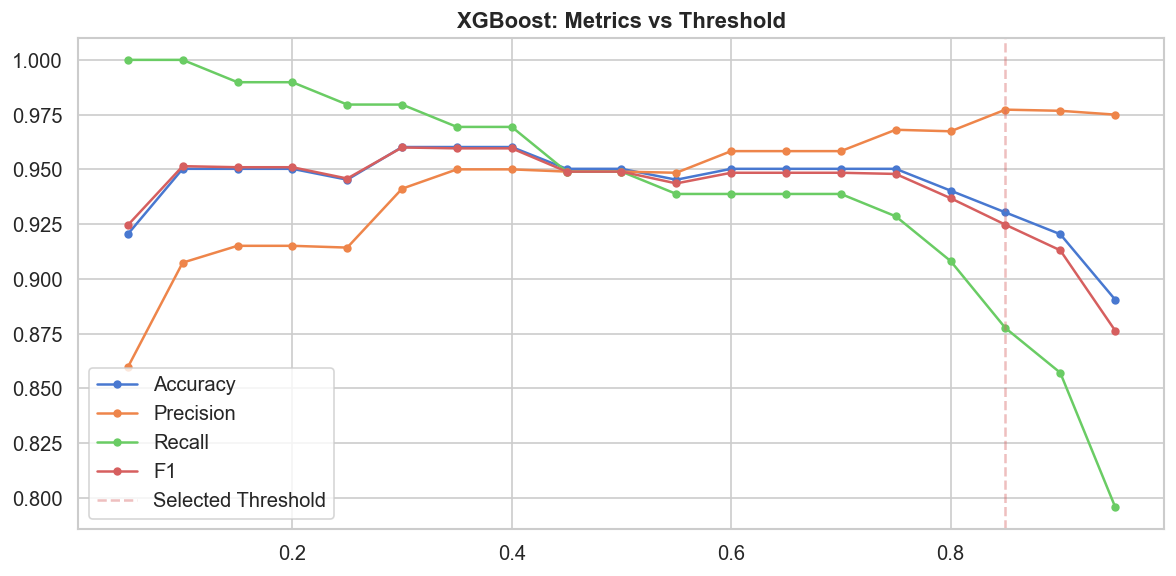

In [23]:
# XGBoost threshold sweep (accuracy, precision, recall, F1).
thresholds = np.linspace(0.05, 0.95, 19)
xgb_sweep = pd.DataFrame([{
    'threshold': t,
    'accuracy': accuracy_score(y_test, (xgb_prob>=t).astype(int)),
    'precision': precision_score(y_test, (xgb_prob>=t).astype(int), zero_division=0),
    'recall': recall_score(y_test, (xgb_prob>=t).astype(int), zero_division=0),
    'f1': f1_score(y_test, (xgb_prob>=t).astype(int), zero_division=0)
} for t in thresholds])

fig, ax = plt.subplots(figsize=(10, 5))
for m in ['accuracy','precision','recall','f1']:
    ax.plot(xgb_sweep['threshold'], xgb_sweep[m], marker='o', markersize=4, label=m.title())
ax.axvline(ENGAGEMENT_THRESHOLD, color='r', ls='--', alpha=0.4, label='Selected Threshold')
ax.set_title("XGBoost: Metrics vs Threshold", fontweight='bold')
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(XGBOOST_REPORT_DIR, "threshold_sweep_plot.png"), dpi=150, bbox_inches="tight")
plt.show()


In [24]:
# Helper for the next XGBoost feature-importance cell.
# This stays close to the plot/report code that uses it.

def _feature_importance_frame(booster: xgb.Booster, top_n: int = 20) -> pd.DataFrame:
    """Return gain-based feature importance in a report-friendly dataframe."""
    score = booster.get_score(importance_type="gain")
    if not score:
        return pd.DataFrame(columns=["feature", "gain"])
    return (
        pd.DataFrame({"feature": list(score.keys()), "gain": list(score.values())})
        .sort_values("gain", ascending=False)
        .head(top_n)
    )


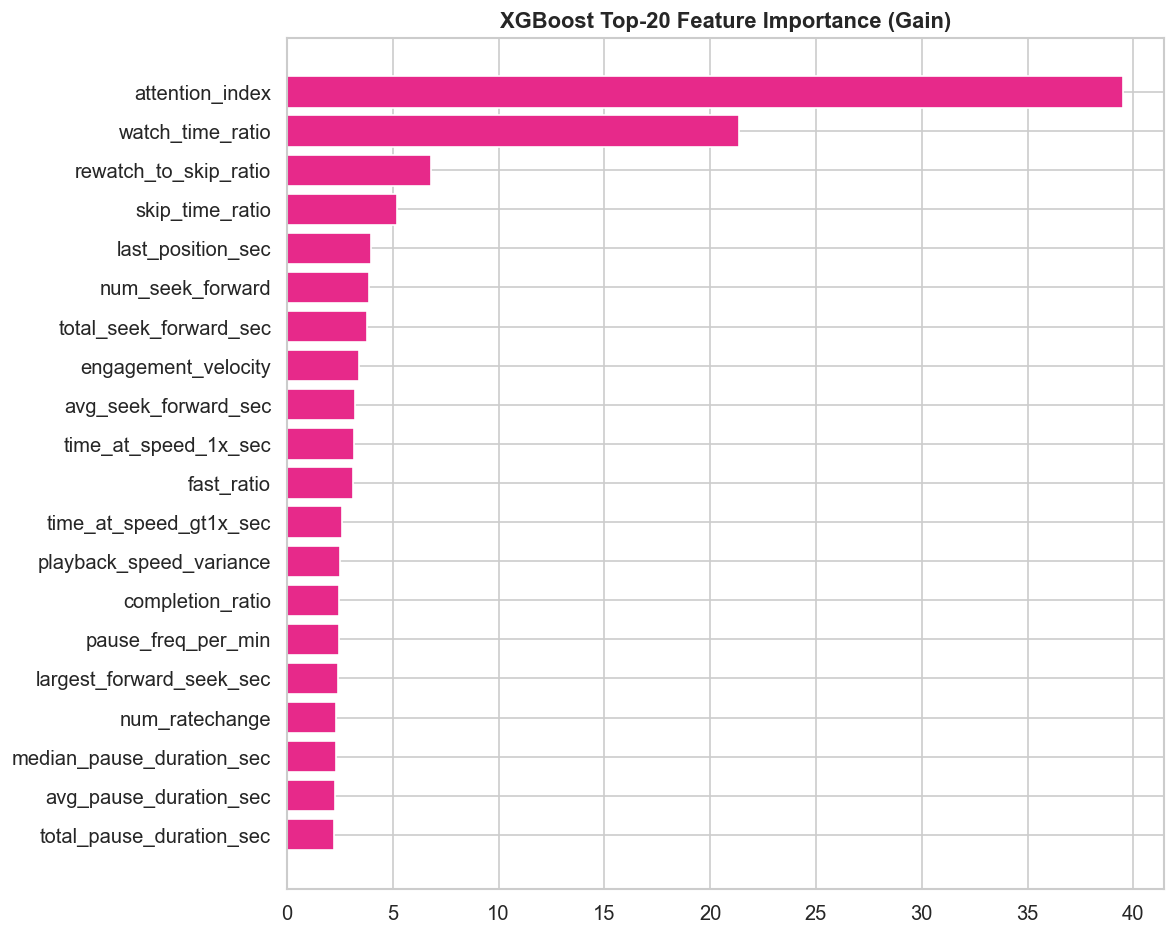

In [25]:
# XGBoost feature importance + SHAP
xgb_imp_df = _feature_importance_frame(xgb_model, top_n=len(FEATURE_COLS))

fig, ax = plt.subplots(figsize=(10, 8))
top20 = xgb_imp_df.head(20).sort_values("gain", ascending=True)
ax.barh(top20["feature"], top20["gain"], color="#e7298a")
ax.set_title("XGBoost Top-20 Feature Importance (Gain)", fontweight="bold")
plt.tight_layout(); plt.show()

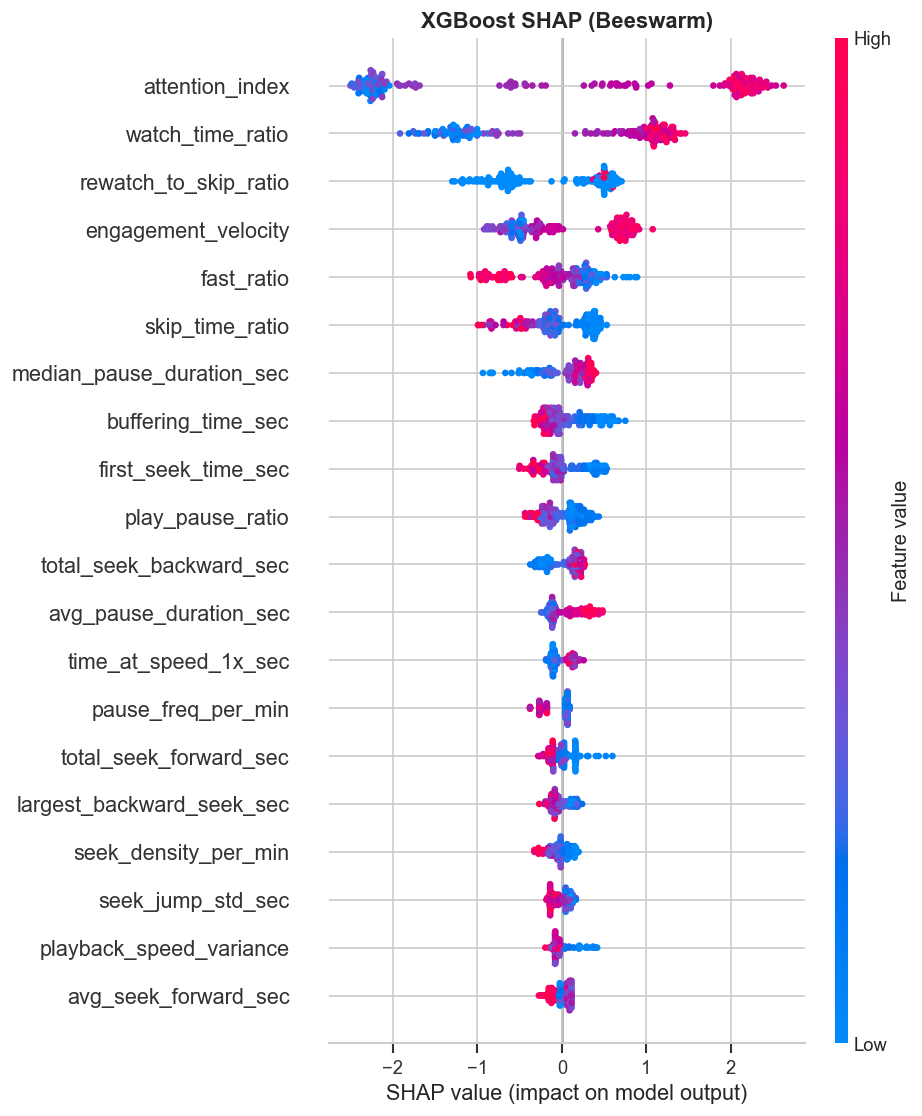

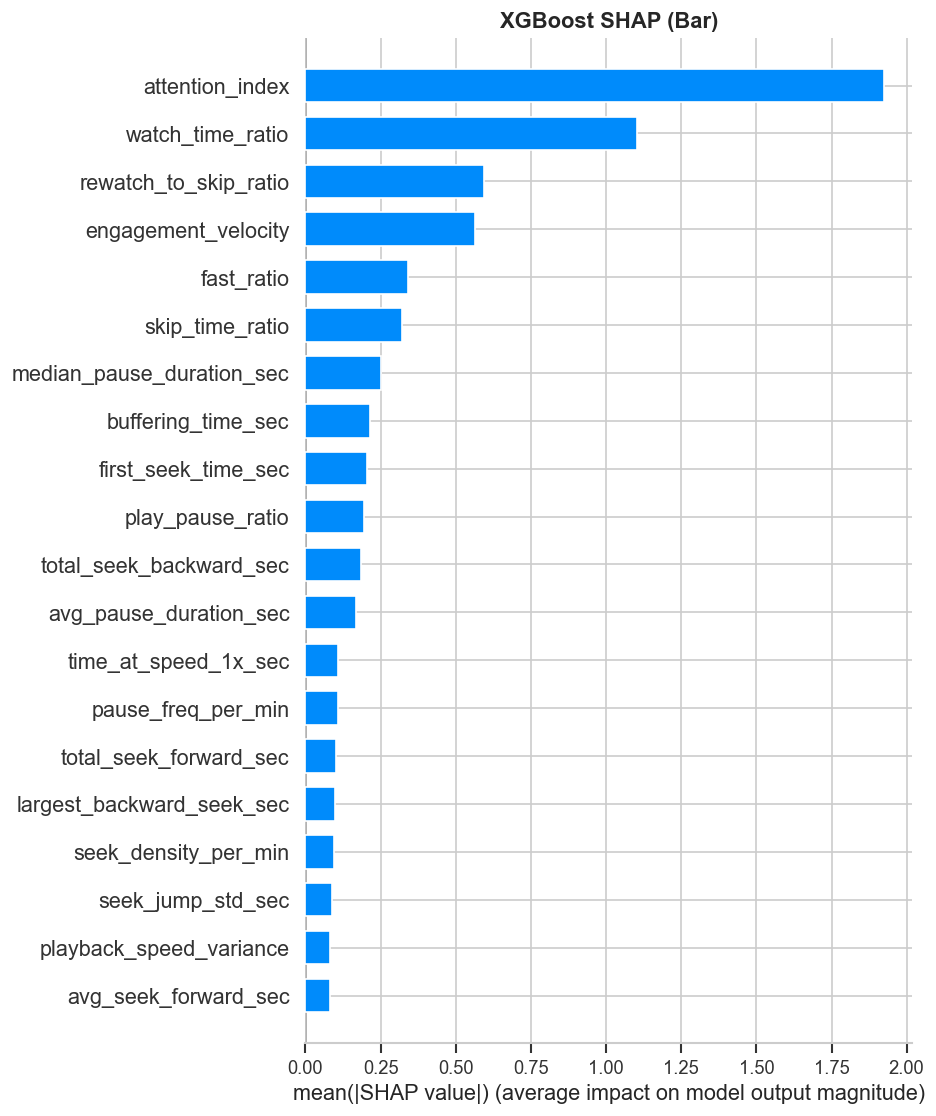

In [26]:
# XGBoost SHAP
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

fig = plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, max_display=20, show=False)
plt.title("XGBoost SHAP (Beeswarm)", fontweight='bold')
plt.tight_layout(); plt.show()

fig = plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, plot_type='bar', max_display=20, show=False)
plt.title("XGBoost SHAP (Bar)", fontweight='bold')
plt.tight_layout(); plt.show()

### XGBoost: Local SHAP Explanations (Per-Session)

Compute per-session SHAP values — shows exactly which features pushed a prediction toward engaged/not-engaged. Same logic as `xgboost/explain/shap_explain.py`.

In [27]:
# XGBoost local SHAP: explain a single test session
def compute_local_shap_xgb(model, sample_df, feature_cols):
    """Compute local SHAP values for a single sample using the tuned Booster."""
    exp = shap.TreeExplainer(model)
    sv = exp.shap_values(sample_df)
    if isinstance(sv, list):
        sv = sv[1] if len(sv) > 1 else sv[0]
    result = []
    for i, col in enumerate(feature_cols):
        result.append({"feature": col, "value": float(sample_df[col].values[0]), "shap": float(sv[0][i])})
    return result


def top_contributors(shap_rows, k=3):
    sorted_rows = sorted(shap_rows, key=lambda r: r["shap"])
    return sorted_rows[:k], list(reversed(sorted_rows[-k:]))


sample_xgb = X_test.iloc[0:1]
sample_session_id = test_df.iloc[0]["session_id"]
local_shap = compute_local_shap_xgb(xgb_model, sample_xgb, FEATURE_COLS)
top_neg, top_pos = top_contributors(local_shap, k=5)

print(f"=== XGBoost Local SHAP Explanation (Session {sample_session_id}) ===")
print(f"Predicted:  {xgb_prob[0]:.4f}  |  Actual: {y_test.iloc[0]}")
print()
print("Top 5 features pushing toward engaged:")
for r in top_pos:
    print(f"   {r['feature']:35s}  value={r['value']:8.3f}  shap={r['shap']:+.4f}")
print()
print("Top 5 features pushing toward not-engaged:")
for r in top_neg:
    print(f"   {r['feature']:35s}  value={r['value']:8.3f}  shap={r['shap']:+.4f}")

=== XGBoost Local SHAP Explanation (Session 9ce9b0ae-faf6-418f-a12c-f61f9ebb502c) ===
Predicted:  0.4266  |  Actual: 1

Top 5 features pushing toward engaged:
   watch_time_ratio                     value=   0.602  shap=+1.0906
   engagement_velocity                  value=   1.359  shap=+0.9136
   total_seek_backward_sec              value= 485.708  shap=+0.1832
   time_at_speed_1x_sec                 value= 551.375  shap=+0.1424
   deep_flag                            value=   1.000  shap=+0.1416

Top 5 features pushing toward not-engaged:
   rewatch_to_skip_ratio                value=   0.522  shap=-0.9392
   attention_index                      value=   0.249  shap=-0.4395
   first_seek_time_sec                  value= 155.830  shap=-0.3325
   play_pause_ratio                     value=   1.250  shap=-0.2388
   buffering_time_sec                   value=   4.312  shap=-0.1681


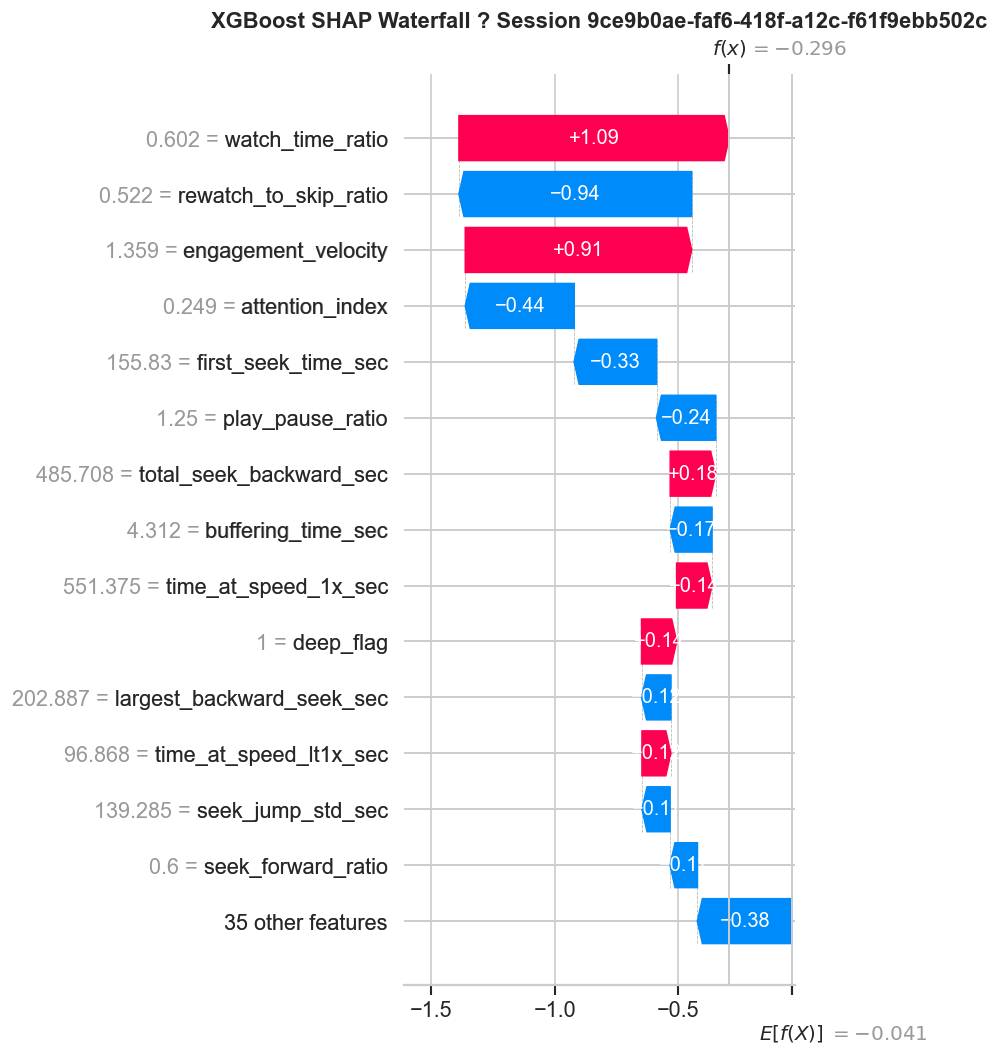

In [28]:
# XGBoost SHAP waterfall for a single session
shap_exp = shap.TreeExplainer(xgb_model)
sv_single = shap_exp(X_test.iloc[0:1])
sample_session_id = test_df.iloc[0]["session_id"]

fig = plt.figure(figsize=(12, 8))
shap.plots.waterfall(sv_single[0], max_display=15, show=False)
plt.title(f"XGBoost SHAP Waterfall ? Session {sample_session_id}", fontweight="bold")
plt.tight_layout(); plt.show()

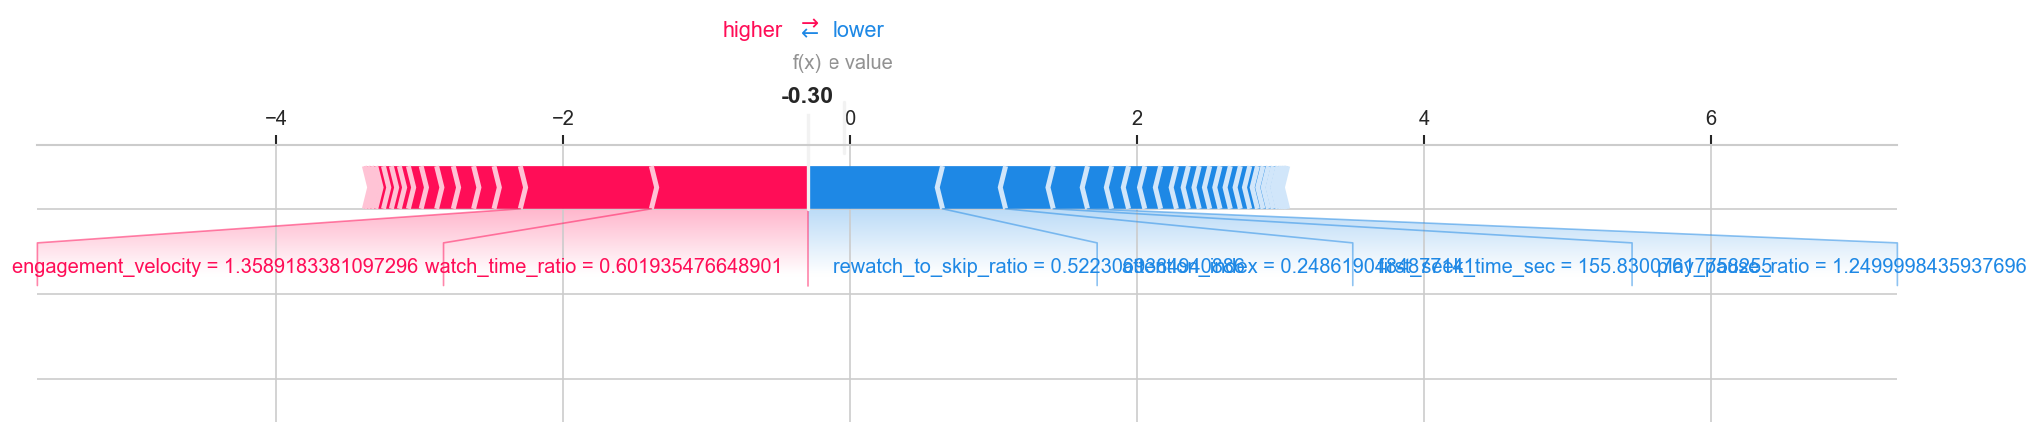

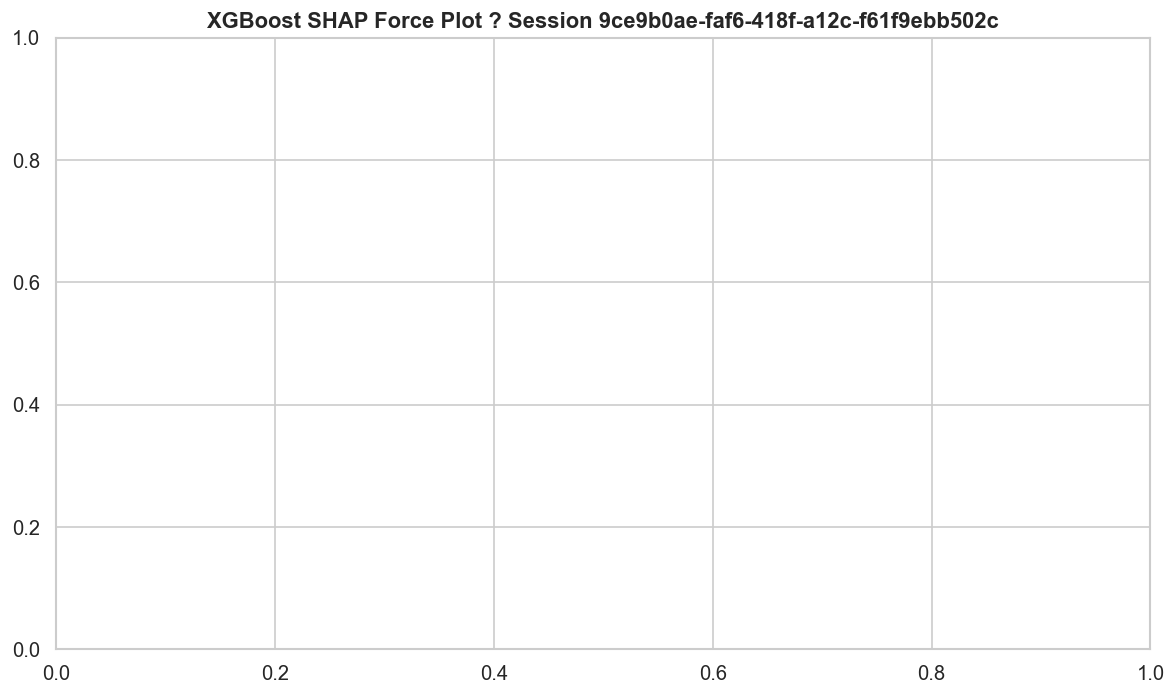

In [29]:
# XGBoost SHAP force plot for a single session
shap.initjs()
sample_session_id = test_df.iloc[0]["session_id"]
shap.force_plot(shap_exp.expected_value, shap_exp.shap_values(X_test.iloc[0:1]), X_test.iloc[0:1], matplotlib=True)
plt.title(f"XGBoost SHAP Force Plot ? Session {sample_session_id}", fontweight="bold")
plt.tight_layout(); plt.show()

---
## Model B - Explainable Boosting Machine (EBM)

Train and evaluate EBM with grouped CV random search and held-out testing.


In [30]:
# Helper functions for the next EBM tuning/evaluation cell.
# Keep them next to the EBM training logic so this file reads top-to-bottom.

def sample_ebm_params(rng: np.random.Generator) -> dict[str, object]:
    """Sample one random hyperparameter combination from the EBM search space."""
    return {
        "max_bins": int(rng.choice([128, 256, 512])),
        "learning_rate": float(rng.choice([0.005, 0.01, 0.02, 0.03, 0.05, 0.08])),
        "max_leaves": int(rng.choice([2, 3, 4, 5, 6])),
        "min_samples_leaf": int(rng.choice([2, 4, 5, 8, 10, 15])),
        "interactions": int(rng.choice([0, 3, 5, 8, 10])),
        "max_interaction_bins": int(rng.choice([16, 32, 64])),
    }

def make_ebm_cv_folds(df_train: pd.DataFrame, feature_columns: list[str]) -> list[tuple[np.ndarray, np.ndarray]]:
    """Build grouped CV folds so user_id does not leak between folds."""
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
    y = df_train["engagement_label"].astype(int).values
    groups = df_train["user_id"].astype(str).values
    x_dummy = df_train[feature_columns].values

    folds: list[tuple[np.ndarray, np.ndarray]] = []
    for tr_idx, va_idx in sgkf.split(x_dummy, y, groups):
        folds.append((tr_idx, va_idx))
    return folds

def compute_ebm_metrics(y_true: np.ndarray, y_prob: np.ndarray) -> dict[str, object]:
    """Compute the held-out evaluation metrics used in reports and metadata."""
    y_pred_05 = (y_prob >= 0.5).astype(int)
    y_pred_085 = (y_prob >= ENGAGEMENT_THRESHOLD).astype(int)

    return {
        "auc_roc": float(roc_auc_score(y_true, y_prob)),
        "auc_pr": float(average_precision_score(y_true, y_prob)),
        "accuracy_0.5": float(accuracy_score(y_true, y_pred_05)),
        "precision_0.5": float(precision_score(y_true, y_pred_05, zero_division=0)),
        "recall_0.5": float(recall_score(y_true, y_pred_05, zero_division=0)),
        "f1_0.5": float(f1_score(y_true, y_pred_05, zero_division=0)),
        "accuracy_0.85": float(accuracy_score(y_true, y_pred_085)),
        "precision_0.85": float(precision_score(y_true, y_pred_085, zero_division=0)),
        "recall_0.85": float(recall_score(y_true, y_pred_085, zero_division=0)),
        "f1_0.85": float(f1_score(y_true, y_pred_085, zero_division=0)),
        "confusion_matrix_0.85": confusion_matrix(y_true, y_pred_085).tolist(),
        "threshold_used": ENGAGEMENT_THRESHOLD,
    }

def build_ebm_predictions_frame(test_df: pd.DataFrame, y_prob: np.ndarray) -> pd.DataFrame:
    """Attach probabilities and threshold-based error labels to test rows."""
    predictions = test_df[["user_id", "session_id", "engagement_label"]].copy()
    predictions["y_prob"] = y_prob
    predictions["y_pred_0.5"] = (y_prob >= 0.5).astype(int)
    predictions["y_pred_0.85"] = (y_prob >= ENGAGEMENT_THRESHOLD).astype(int)

    def classify_error(row: pd.Series) -> str:
        if row["engagement_label"] == row["y_pred_0.85"]:
            return "correct"
        if row["y_pred_0.85"] == 1:
            return "false_positive"
        return "false_negative"

    predictions["error_type_0.85"] = predictions.apply(classify_error, axis=1)
    return predictions

def train_ebm_fold(
    train_frame: pd.DataFrame,
    val_frame: pd.DataFrame,
    feature_columns: list[str],
    params: dict[str, object],
) -> float:
    """Train one EBM CV fold with preprocessing fitted only on that fold's train split."""
    fold_preprocessing = fit_numeric_preprocessing(train_frame[feature_columns])
    x_train = transform_numeric_frame(train_frame[feature_columns], fold_preprocessing).values
    x_val = transform_numeric_frame(val_frame[feature_columns], fold_preprocessing).values
    y_train = train_frame["engagement_label"].astype(int).values
    y_val = val_frame["engagement_label"].astype(int).values

    ebm = ExplainableBoostingClassifier(
        feature_names=feature_columns,
        max_bins=int(params["max_bins"]),
        learning_rate=float(params["learning_rate"]),
        max_leaves=int(params["max_leaves"]),
        min_samples_leaf=int(params["min_samples_leaf"]),
        interactions=int(params["interactions"]),
        max_interaction_bins=int(params["max_interaction_bins"]),
        max_rounds=500,
        outer_bags=1,
        validation_size=0.0,
        random_state=SEED,
        n_jobs=-1,
    )
    ebm.fit(x_train, y_train)
    y_prob = ebm.predict_proba(x_val)[:, 1]
    return float(roc_auc_score(y_val, y_prob))

def _build_ebm_model(feature_columns: list[str], params: dict[str, object]) -> ExplainableBoostingClassifier:
    """Build the final EBM model used for held-out eval and production retraining."""
    return ExplainableBoostingClassifier(
        feature_names=feature_columns,
        max_bins=int(params["max_bins"]),
        learning_rate=float(params["learning_rate"]),
        max_leaves=int(params["max_leaves"]),
        min_samples_leaf=int(params["min_samples_leaf"]),
        interactions=int(params["interactions"]),
        max_interaction_bins=int(params["max_interaction_bins"]),
        max_rounds=5000,
        early_stopping_rounds=50,
        validation_size=0.15,
        random_state=SEED,
        n_jobs=-1,
    )


In [31]:
# EBM tuning flow:
# 1) grouped CV random search picks hyperparameters
# 2) one evaluation model is trained on train_df
# 3) held-out test_df is scored once at the end
rng = np.random.default_rng(SEED)
ebm_folds = make_ebm_cv_folds(train_df, FEATURE_COLS)
ebm_best = {"mean_auc": -1.0, "params": None, "all_results": []}

for trial in range(1, N_RANDOM_TRIALS + 1):
    params = sample_ebm_params(rng)
    fold_aucs = []

    for tr_idx, va_idx in ebm_folds:
        train_fold = train_df.iloc[tr_idx]
        val_fold = train_df.iloc[va_idx]
        try:
            fold_aucs.append(train_ebm_fold(train_fold, val_fold, FEATURE_COLS, params))
        except Exception as exc:
            print(f"Trial {trial}: fold failed with {exc}")
            fold_aucs.append(0.0)

    mean_auc = float(np.mean(fold_aucs))
    std_auc = float(np.std(fold_aucs))
    trial_result = {
        "trial": trial,
        "params": params,
        "mean_auc": mean_auc,
        "std_auc": std_auc,
        "fold_aucs": fold_aucs,
    }
    ebm_best["all_results"].append(trial_result)

    if mean_auc > ebm_best["mean_auc"]:
        ebm_best["mean_auc"] = mean_auc
        ebm_best["params"] = params
        ebm_best["fold_aucs"] = fold_aucs
        print(f"Trial {trial}/{N_RANDOM_TRIALS}: new best EBM AUC={mean_auc:.4f} ? {std_auc:.4f}")

if ebm_best["params"] is None:
    raise RuntimeError("EBM tuning failed.")

ebm_model = _build_ebm_model(FEATURE_COLS, ebm_best["params"])
ebm_model.fit(X_train.values, y_train.values)

ebm_prob = ebm_model.predict_proba(X_test.values)[:, 1]
ebm_pred = ebm_model.predict(X_test.values)
ebm_metrics = compute_ebm_metrics(y_test.values, ebm_prob)
ebm_metrics["cv_best_auc"] = float(ebm_best["mean_auc"])
ebm_predictions_df = build_ebm_predictions_frame(test_df, ebm_prob)
ebm_cv = np.array(ebm_best["fold_aucs"])

print("EBM evaluation model trained.")
print(f"Best CV AUC:     {ebm_best['mean_auc']:.4f}")
print(f"Held-out AUC:    {ebm_metrics['auc_roc']:.4f}")
print(f"Held-out AUC-PR: {ebm_metrics['auc_pr']:.4f}")


Trial 1/40: new best EBM AUC=0.9831 ? 0.0057
Trial 3/40: new best EBM AUC=0.9844 ? 0.0049
Trial 6/40: new best EBM AUC=0.9873 ? 0.0025
Trial 25/40: new best EBM AUC=0.9883 ? 0.0033
EBM evaluation model trained.
Best CV AUC:     0.9883
Held-out AUC:    0.9895
Held-out AUC-PR: 0.9887


In [32]:
# EBM tuning summary
ebm_cv_results_df = (
    pd.DataFrame([
        {
            "trial": result["trial"],
            "mean_auc": result["mean_auc"],
            "std_auc": result["std_auc"],
        }
        for result in ebm_best["all_results"]
    ])
    .sort_values("mean_auc", ascending=False)
    .reset_index(drop=True)
)

print(f"EBM 5-fold grouped CV AUC (best trial): {ebm_cv.mean():.4f} +/- {ebm_cv.std():.4f}")
ebm_cv_results_df.head(10)

EBM 5-fold grouped CV AUC (best trial): 0.9883 +/- 0.0033


,trial,mean_auc,std_auc
0,25,0.9883,0.0033
1,6,0.9873,0.0025
2,15,0.9871,0.0030
3,12,0.9871,0.0020
4,8,0.9867,0.0036
5,20,0.9864,0.0029
6,29,0.9863,0.0039
7,3,0.9844,0.0049
8,16,0.9844,0.0062
9,11,0.9840,0.0046


In [33]:
# EBM evaluation report.
print("=" * 60)
print("EBM CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, ebm_pred, target_names=["Not Engaged", "Engaged"]))
print(f"AUC-ROC:       {ebm_metrics['auc_roc']:.4f}")
print(f"AUC-PR:        {ebm_metrics['auc_pr']:.4f}")
print(f"Accuracy@0.85: {ebm_metrics['accuracy_0.85']:.4f}")
print(f"F1@0.85:       {ebm_metrics['f1_0.85']:.4f}")

with open(os.path.join(EBM_REPORT_DIR, "classification_report.txt"), "w", encoding="utf-8") as f:
    f.write(classification_report(y_test, ebm_pred, target_names=["Not Engaged", "Engaged"]))


EBM CLASSIFICATION REPORT
              precision    recall  f1-score   support

 Not Engaged       0.95      0.94      0.95       103
     Engaged       0.94      0.95      0.94        98

    accuracy                           0.95       201
   macro avg       0.95      0.95      0.95       201
weighted avg       0.95      0.95      0.95       201

AUC-ROC:       0.9895
AUC-PR:        0.9887
Accuracy@0.85: 0.9204
F1@0.85:       0.9149


In [ ]:
# EBM confusion matrix, ROC, and PR curves saved as separate figures.
combined_eval_path = os.path.join(EBM_REPORT_DIR, "eval_confusion_roc_pr.png")
if os.path.exists(combined_eval_path):
    os.remove(combined_eval_path)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, ebm_pred, display_labels=['Not Engaged','Engaged'], cmap='Purples', ax=ax)
ax.set_title("EBM CM (t=0.5)")
plt.tight_layout()
fig.savefig(os.path.join(EBM_REPORT_DIR, "eval_confusion_t05.png"), dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, (ebm_prob>=ENGAGEMENT_THRESHOLD).astype(int), display_labels=['Not Engaged','Engaged'], cmap='Oranges', ax=ax)
ax.set_title(f"EBM CM (t={ENGAGEMENT_THRESHOLD:.2f})")
plt.tight_layout()
fig.savefig(os.path.join(EBM_REPORT_DIR, "eval_confusion_threshold.png"), dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, ebm_prob, ax=ax)
ax.plot([0,1],[0,1],'k--',alpha=0.3)
ax.set_title("EBM ROC")
plt.tight_layout()
fig.savefig(os.path.join(EBM_REPORT_DIR, "eval_roc_curve.png"), dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(y_test, ebm_prob, ax=ax)
ax.set_title("EBM Precision-Recall")
plt.tight_layout()
fig.savefig(os.path.join(EBM_REPORT_DIR, "eval_pr_curve.png"), dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# EBM calibration and score distribution saved as separate figures.
combined_calibration_path = os.path.join(EBM_REPORT_DIR, "eval_calibration_distribution.png")
if os.path.exists(combined_calibration_path):
    os.remove(combined_calibration_path)

fig, ax = plt.subplots(figsize=(7, 5))
CalibrationDisplay.from_predictions(y_test, ebm_prob, n_bins=10, strategy='quantile', ax=ax)
ax.set_title("EBM Calibration")
plt.tight_layout()
fig.savefig(os.path.join(EBM_REPORT_DIR, "eval_calibration.png"), dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(ebm_prob[y_test==0], bins=30, alpha=0.6, label='Not Engaged', color='#d95f02')
ax.hist(ebm_prob[y_test==1], bins=30, alpha=0.6, label='Engaged', color='#1b9e77')
ax.axvline(0.5, color='k', ls='--', alpha=0.4)
ax.axvline(ENGAGEMENT_THRESHOLD, color='r', ls='--', alpha=0.4)
ax.set_title("EBM Score Distribution")
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(EBM_REPORT_DIR, "eval_score_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()


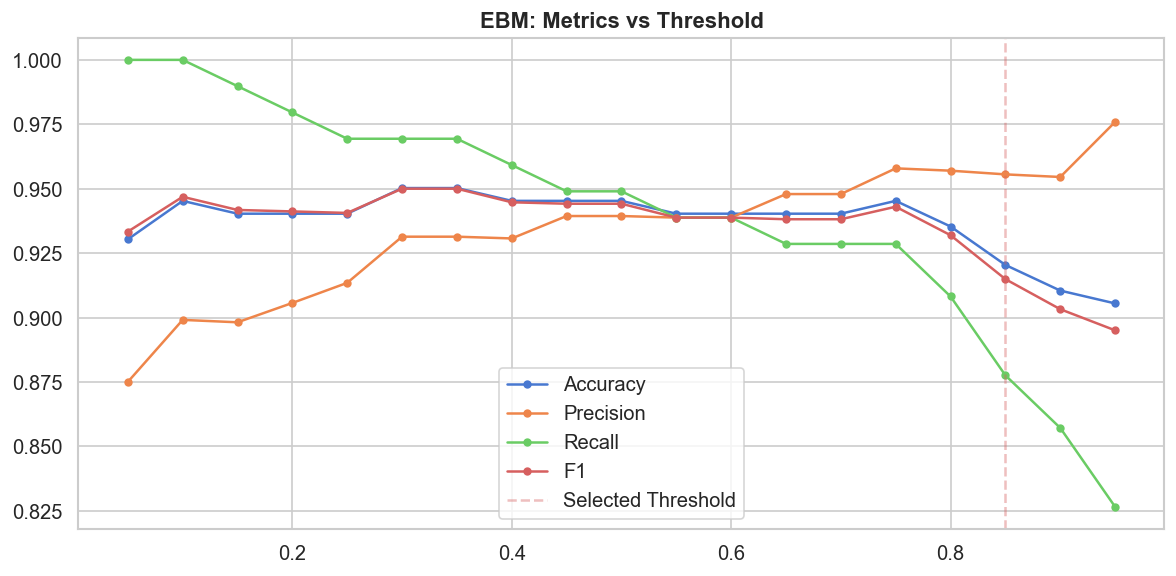

In [36]:
# EBM threshold sweep (accuracy, precision, recall, F1).
ebm_sweep = pd.DataFrame([{
    'threshold': t,
    'accuracy': accuracy_score(y_test, (ebm_prob>=t).astype(int)),
    'precision': precision_score(y_test, (ebm_prob>=t).astype(int), zero_division=0),
    'recall': recall_score(y_test, (ebm_prob>=t).astype(int), zero_division=0),
    'f1': f1_score(y_test, (ebm_prob>=t).astype(int), zero_division=0)
} for t in thresholds])

fig, ax = plt.subplots(figsize=(10, 5))
for m in ['accuracy','precision','recall','f1']:
    ax.plot(ebm_sweep['threshold'], ebm_sweep[m], marker='o', markersize=4, label=m.title())
ax.axvline(ENGAGEMENT_THRESHOLD, color='r', ls='--', alpha=0.4, label='Selected Threshold')
ax.set_title("EBM: Metrics vs Threshold", fontweight='bold')
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(EBM_REPORT_DIR, "threshold_sweep_plot.png"), dpi=150, bbox_inches="tight")
plt.show()


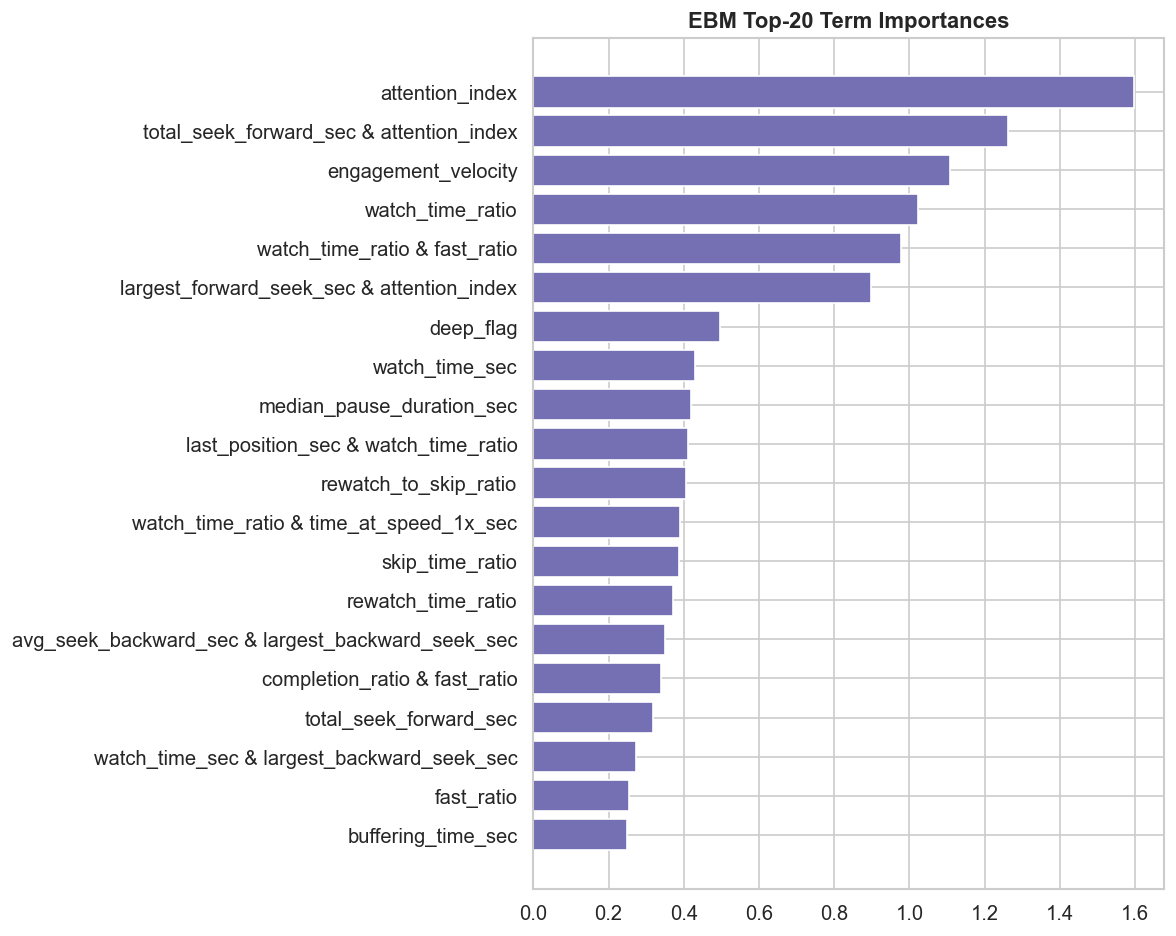

In [37]:
# EBM term importances
ebm_importances = ebm_model.term_importances()
ebm_names = ebm_model.term_names_
ebm_imp_df = pd.DataFrame({'feature': ebm_names, 'importance': ebm_importances}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top20_ebm = ebm_imp_df.head(20).sort_values('importance', ascending=True)
ax.barh(top20_ebm['feature'], top20_ebm['importance'], color='#7570b3')
ax.set_title("EBM Top-20 Term Importances", fontweight='bold')
plt.tight_layout(); plt.show()

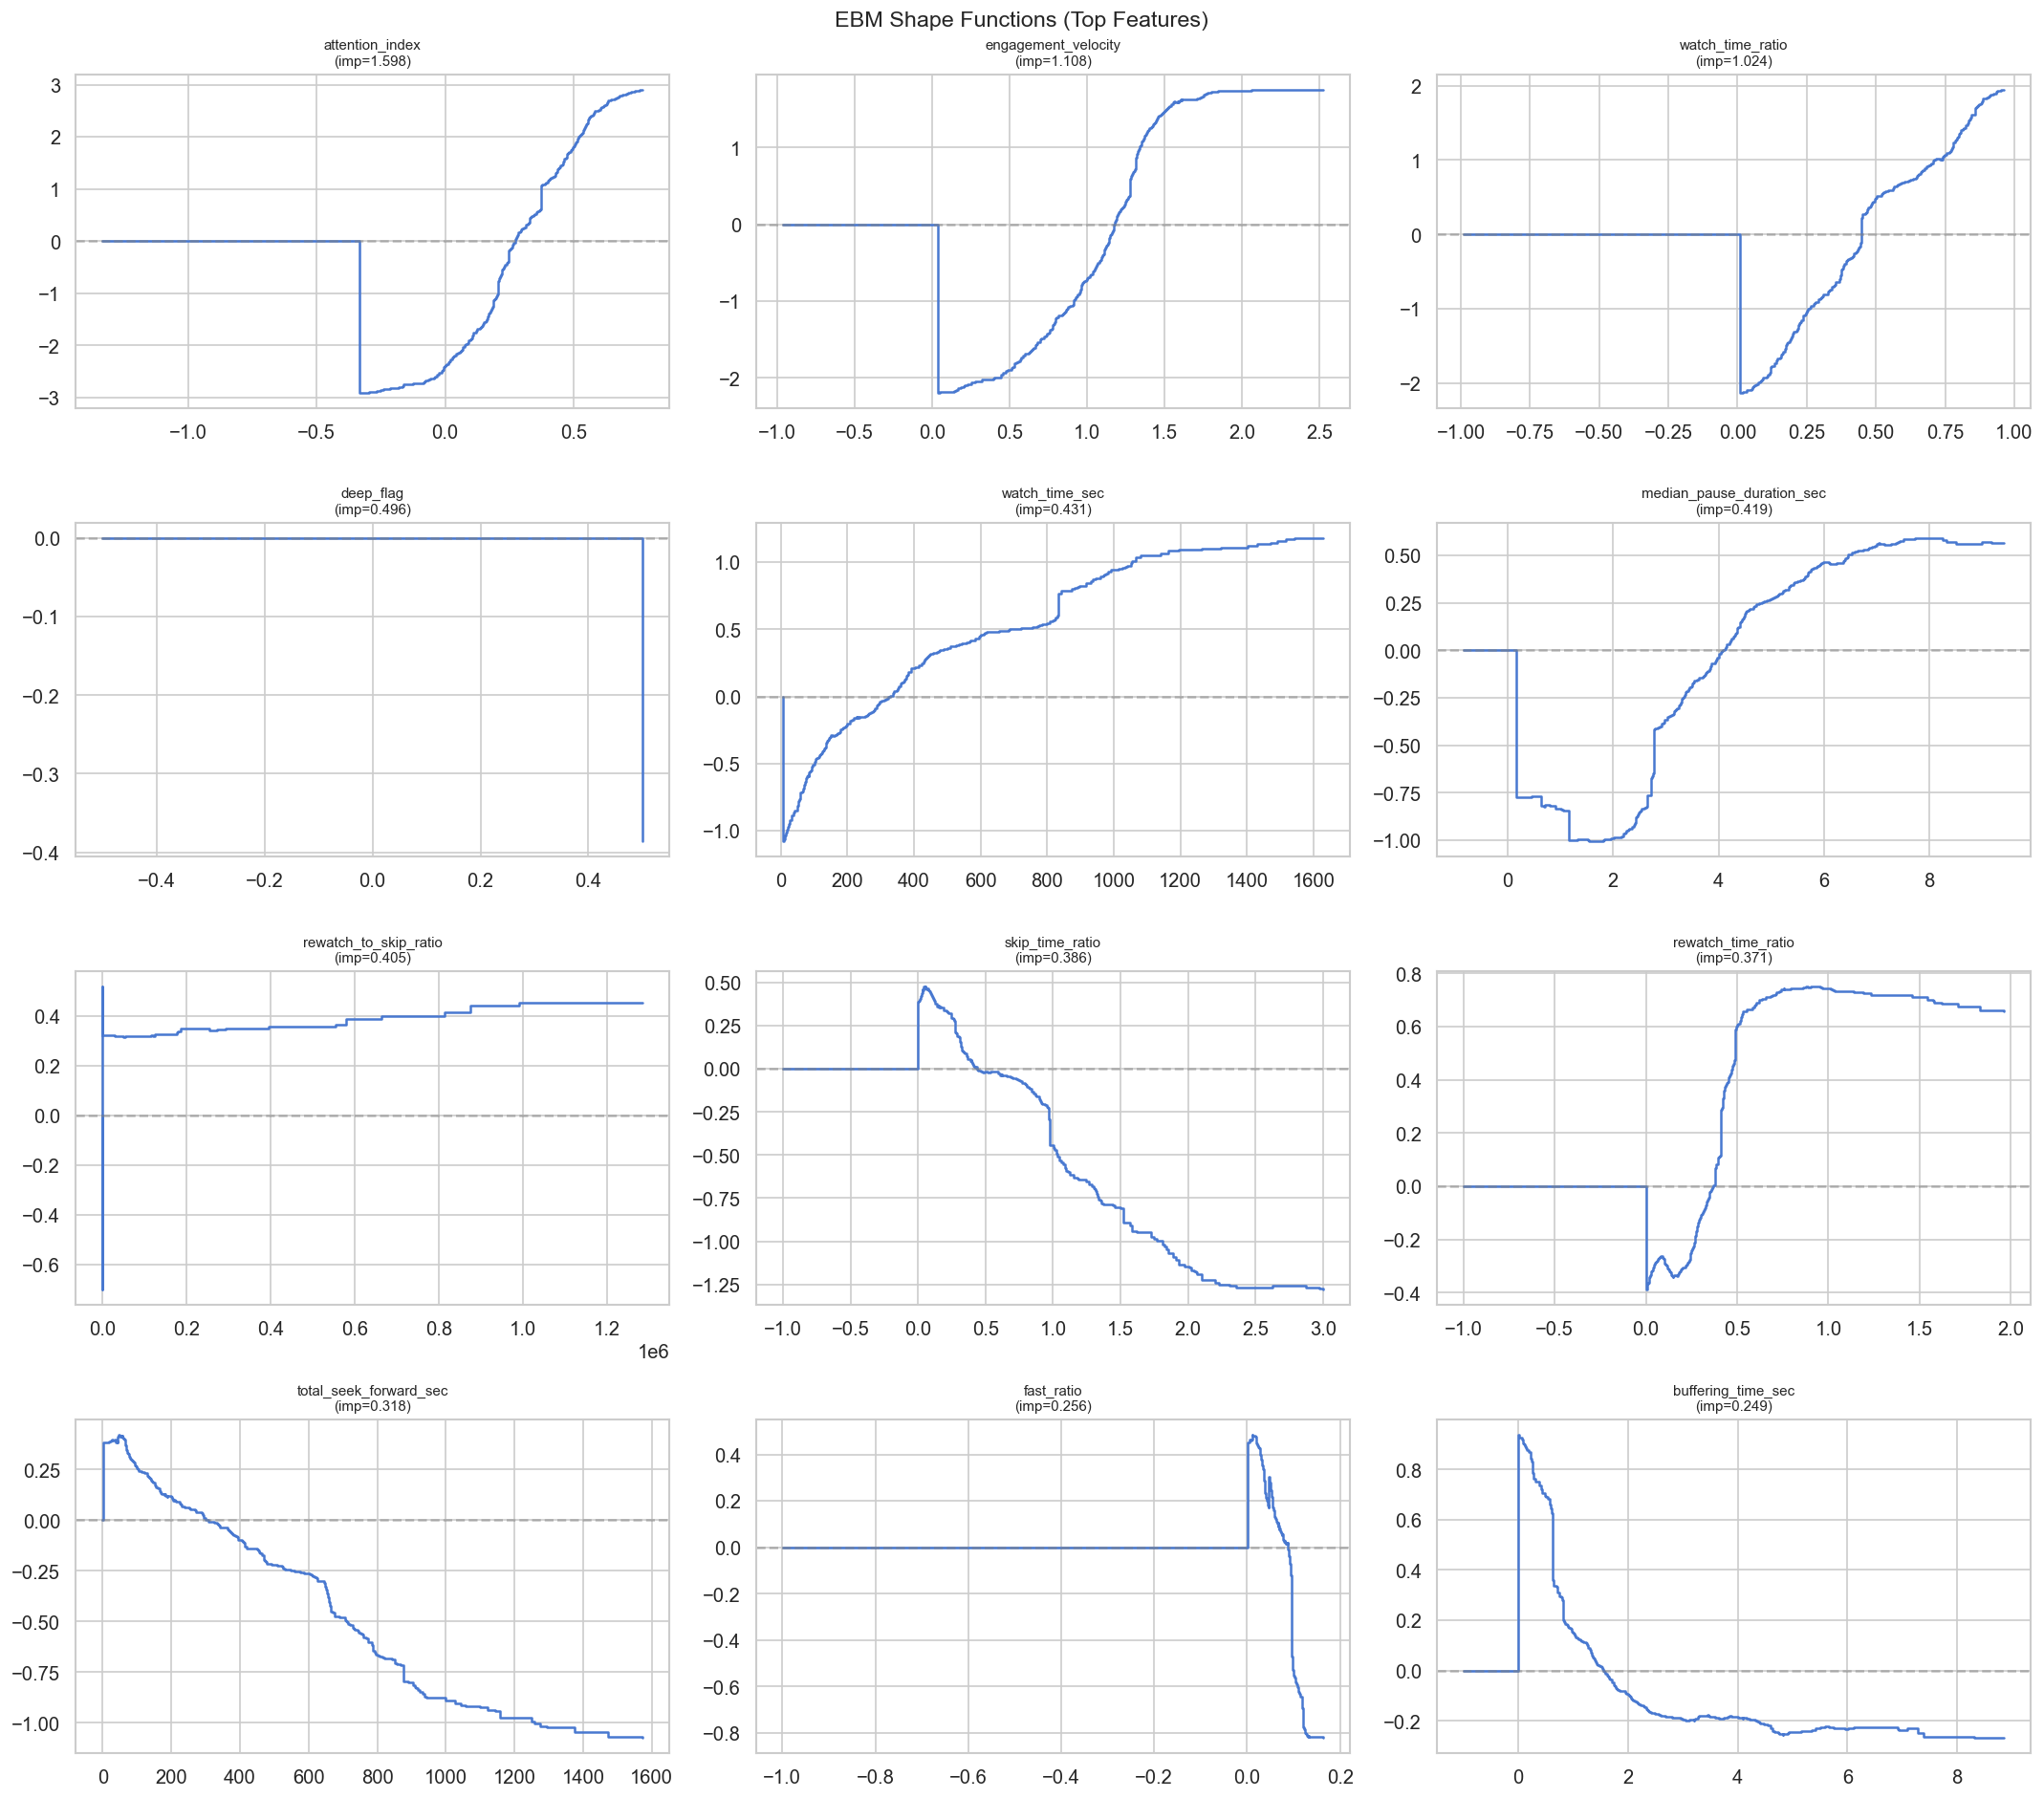

In [38]:
# EBM shape functions (top 12 features)
try:
    plottable = []
    for idx in range(len(ebm_importances)):
        scores = ebm_model.term_scores_[idx]
        if scores.ndim != 1: continue
        bins_list = ebm_model.bins_[idx]
        if not bins_list or len(bins_list) == 0: continue
        plottable.append((idx, ebm_importances[idx]))
    plottable.sort(key=lambda x: x[1], reverse=True)
    plottable = plottable[:12]

    n_plots = len(plottable)
    fig, axes = plt.subplots((n_plots+2)//3, 3, figsize=(18, 4*((n_plots+2)//3)))
    axes = axes.flatten()
    for i, (tidx, imp) in enumerate(plottable):
        ax = axes[i]
        bins = ebm_model.bins_[tidx][0]
        scores = ebm_model.term_scores_[tidx]
        x_vals = np.concatenate([[bins[0]-1], bins])
        y_vals = scores[:len(x_vals)]
        ax.step(x_vals, y_vals, where='post', linewidth=1.5)
        ax.axhline(0, color='gray', ls='--', alpha=0.5)
        ax.set_title(f"{ebm_model.term_names_[tidx]}\n(imp={imp:.3f})", fontsize=9)
    for i in range(n_plots, len(axes)): axes[i].set_visible(False)
    plt.suptitle("EBM Shape Functions (Top Features)", fontsize=14)
    plt.tight_layout(); plt.show()
except Exception as e:
    print(f"Shape function plots skipped: {e}")

### EBM: Local Glass-Box Explanations (Per-Session)

EBM is inherently interpretable — each prediction is an exact sum of term contributions.
No SHAP approximation needed. Same logic as `ebm/explain/ebm_explain.py`.

In [39]:
# EBM local explanation: exact term contributions for a single session
def compute_local_ebm(ebm, sample_array, feature_cols):
    """Compute exact local EBM contributions (matches production ebm_explain.py logic)."""
    local_exp = ebm.explain_local(sample_array)
    data = local_exp.data(0)
    term_names = data["names"]
    raw_scores = data["scores"]
    raw_intercept = data.get("intercept", 0.0)

    def extract(s):
        if hasattr(s, "__len__") and len(s) > 1:
            return float(s[1])
        return float(s)

    term_scores = [extract(s) for s in raw_scores]
    intercept = extract(raw_intercept)

    contribution_map = {}
    for name, score in zip(term_names, term_scores):
        name_str = str(name)
        if " x " in name_str:
            parts = [p.strip() for p in name_str.split(" x ")]
            share = score / len(parts)
            for part in parts:
                contribution_map[part] = contribution_map.get(part, 0.0) + share
        else:
            contribution_map[name_str] = contribution_map.get(name_str, 0.0) + score

    computed_logit = intercept + sum(term_scores)
    try:
        predicted_logit = float(ebm.decision_function(sample_array)[0])
        drift = abs(computed_logit - predicted_logit)
        print(f"   Glass-box sanity: drift={drift:.6f} {'OK' if drift < 1e-4 else 'DRIFT'}")
    except Exception:
        pass

    result = []
    for idx, col in enumerate(feature_cols):
        result.append({"feature": col, "value": float(sample_array[0, idx]), "shap": float(contribution_map.get(col, 0.0))})
    return result, intercept


def top_contributors_ebm(rows, k=3):
    sorted_rows = sorted(rows, key=lambda r: r["shap"])
    return sorted_rows[:k], list(reversed(sorted_rows[-k:]))


sample_ebm = X_test.iloc[0:1][FEATURE_COLS].values
sample_session_id = test_df.iloc[0]["session_id"]
ebm_local, ebm_intercept = compute_local_ebm(ebm_model, sample_ebm, FEATURE_COLS)
top_neg_ebm, top_pos_ebm = top_contributors_ebm(ebm_local, k=5)

print(f"=== EBM Local Explanation (Session {sample_session_id}) ===")
print(f"Predicted:  {ebm_prob[0]:.4f}  |  Actual: {y_test.iloc[0]}")
print(f"Intercept (base logit): {ebm_intercept:.4f}")
print()
print("Top 5 features pushing toward engaged:")
for r in top_pos_ebm:
    print(f"   {r['feature']:35s}  value={r['value']:8.3f}  contribution={r['shap']:+.4f}")
print()
print("Top 5 features pushing toward not-engaged:")
for r in top_neg_ebm:
    print(f"   {r['feature']:35s}  value={r['value']:8.3f}  contribution={r['shap']:+.4f}")

   Glass-box sanity: drift=1.178729 DRIFT
=== EBM Local Explanation (Session 9ce9b0ae-faf6-418f-a12c-f61f9ebb502c) ===
Predicted:  0.7916  |  Actual: 1
Intercept (base logit): 0.0000

Top 5 features pushing toward engaged:
   engagement_velocity                  value=   1.359  contribution=+1.0892
   watch_time_sec                       value=1083.484  contribution=+1.0527
   watch_time_ratio                     value=   0.602  contribution=+0.7086
   deep_flag                            value=   1.000  contribution=+0.6945
   avg_seek_backward_sec                value=  80.951  contribution=+0.5995

Top 5 features pushing toward not-engaged:
   total_seek_forward_sec               value= 929.926  contribution=-0.8562
   num_seek_forward                     value=   9.000  contribution=-0.8031
   num_seek                             value=  15.000  contribution=-0.5004
   seek_forward_ratio                   value=   0.600  contribution=-0.4357
   first_seek_time_sec                  

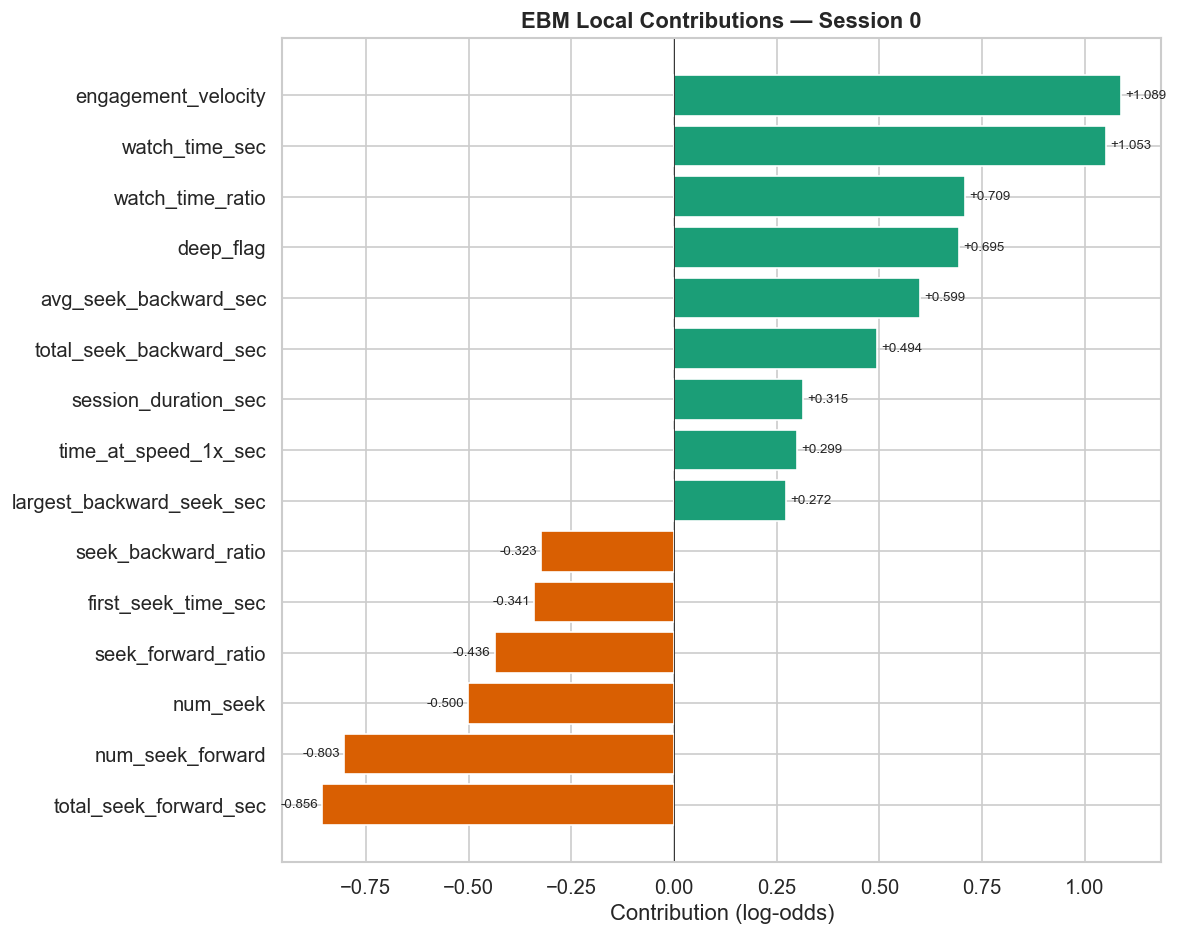

In [40]:
# EBM local contribution waterfall plot
ebm_contrib = pd.DataFrame(ebm_local).sort_values('shap', key=abs, ascending=False).head(15)
ebm_contrib_plot = ebm_contrib.sort_values('shap', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#1b9e77' if v > 0 else '#d95f02' for v in ebm_contrib_plot['shap']]
ax.barh(ebm_contrib_plot['feature'], ebm_contrib_plot['shap'], color=colors)
ax.axvline(0, color='k', lw=0.5)
ax.set_xlabel('Contribution (log-odds)')
ax.set_title(f'EBM Local Contributions — Session {X_test.index[0]}', fontweight='bold')
for i, (f_name, val) in enumerate(zip(ebm_contrib_plot['feature'], ebm_contrib_plot['shap'])):
    ax.text(val + (0.01 if val >= 0 else -0.01), i, f'{val:+.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=8)
plt.tight_layout(); plt.show()

---
## Model Comparison

Compare XGBoost and EBM side-by-side using held-out metrics and CV stability.


In [41]:
# Comparison table.
comparison = pd.DataFrame({
    "Metric": ["AUC-ROC", "AUC-PR", "Accuracy @ 0.5", "F1 @ 0.5", "Accuracy @ 0.85", "F1 @ 0.85", "CV Mean AUC", "Features"],
    "XGBoost": [
        f"{xgb_metrics['auc_roc']:.4f}",
        f"{xgb_metrics['auc_pr']:.4f}",
        f"{xgb_metrics['accuracy_0.5']:.4f}",
        f"{xgb_metrics['f1_0.5']:.4f}",
        f"{xgb_metrics['accuracy_0.85']:.4f}",
        f"{xgb_metrics['f1_0.85']:.4f}",
        f"{xgb_cv.mean():.4f} +/- {xgb_cv.std():.4f}",
        str(len(FEATURE_COLS)),
    ],
    "EBM": [
        f"{ebm_metrics['auc_roc']:.4f}",
        f"{ebm_metrics['auc_pr']:.4f}",
        f"{ebm_metrics['accuracy_0.5']:.4f}",
        f"{ebm_metrics['f1_0.5']:.4f}",
        f"{ebm_metrics['accuracy_0.85']:.4f}",
        f"{ebm_metrics['f1_0.85']:.4f}",
        f"{ebm_cv.mean():.4f} +/- {ebm_cv.std():.4f}",
        str(len(FEATURE_COLS)),
    ],
})
print()
print("=" * 60)
print("MODEL COMPARISON: XGBOOST vs EBM")
print("=" * 60)
comparison



MODEL COMPARISON: XGBOOST vs EBM


,Metric,XGBoost,EBM
0,AUC-ROC,0.9886,0.9895
1,AUC-PR,0.9854,0.9887
2,Accuracy @ 0.5,0.9502,0.9453
3,F1 @ 0.5,0.9490,0.9442
4,Accuracy @ 0.85,0.9303,0.9204
5,F1 @ 0.85,0.9247,0.9149
6,CV Mean AUC,0.9897 +/- 0.0038,0.9883 +/- 0.0033
7,Features,49,49


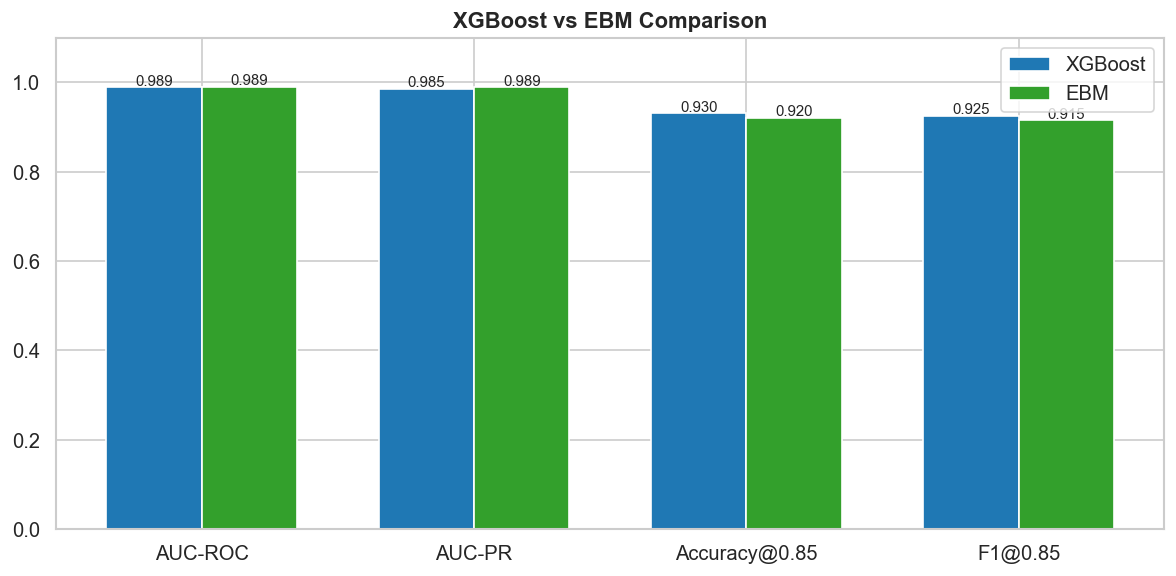

In [42]:
# Visual comparison of key metrics.
metrics_xgb = [xgb_metrics["auc_roc"], xgb_metrics["auc_pr"], xgb_metrics["accuracy_0.85"], xgb_metrics["f1_0.85"]]
metrics_ebm = [ebm_metrics["auc_roc"], ebm_metrics["auc_pr"], ebm_metrics["accuracy_0.85"], ebm_metrics["f1_0.85"]]
labels = ["AUC-ROC", "AUC-PR", "Accuracy@0.85", "F1@0.85"]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(labels)); w = 0.35
b1 = ax.bar(x - w / 2, metrics_xgb, w, label="XGBoost", color="#1f78b4")
b2 = ax.bar(x + w / 2, metrics_ebm, w, label="EBM", color="#33a02c")
for bars in [b1, b2]:
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.005, f"{b.get_height():.3f}", ha="center", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylim(0, 1.1)
ax.set_title("XGBoost vs EBM Comparison", fontweight="bold")
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(ENGAGEMENT_REPORT_DIR, "model_comparison_bar.png"), dpi=150, bbox_inches="tight")
plt.show()


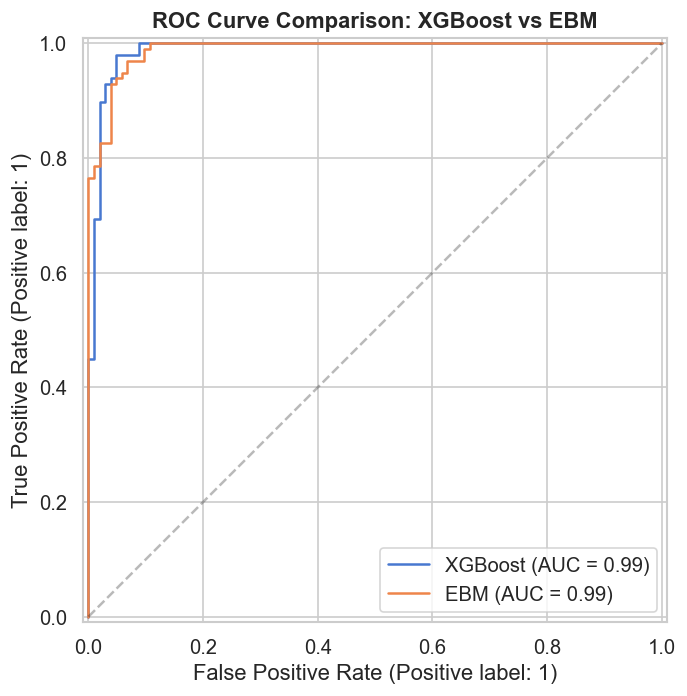

In [43]:
# Overlaid ROC curves.
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, xgb_prob, name='XGBoost', ax=ax)
RocCurveDisplay.from_predictions(y_test, ebm_prob, name='EBM', ax=ax)
ax.plot([0,1],[0,1], 'k--', alpha=0.3)
ax.set_title("ROC Curve Comparison: XGBoost vs EBM", fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(ENGAGEMENT_REPORT_DIR, "model_comparison_roc_overlay.png"), dpi=150, bbox_inches="tight")
plt.show()


In [44]:
# Select best model
xgb_auc = xgb_metrics["auc_roc"]
ebm_auc = ebm_metrics["auc_roc"]

best_model_name = "XGBoost" if xgb_auc >= ebm_auc else "EBM"
print()
print(f"BEST MODEL: {best_model_name}")
print(f"   XGBoost AUC: {xgb_auc:.4f}")
print(f"   EBM AUC:     {ebm_auc:.4f}")


BEST MODEL: EBM
   XGBoost AUC: 0.9886
   EBM AUC:     0.9895


---
## Optional Analysis - Top XGBoost Features


Top 15 XGBoost features (analysis only; training still uses all 49 features):
   1. attention_index
   2. watch_time_ratio
   3. rewatch_to_skip_ratio
   4. skip_time_ratio
   5. last_position_sec
   6. num_seek_forward
   7. total_seek_forward_sec
   8. engagement_velocity
   9. avg_seek_forward_sec
  10. time_at_speed_1x_sec
  11. fast_ratio
  12. time_at_speed_gt1x_sec
  13. playback_speed_variance
  14. completion_ratio
  15. pause_freq_per_min


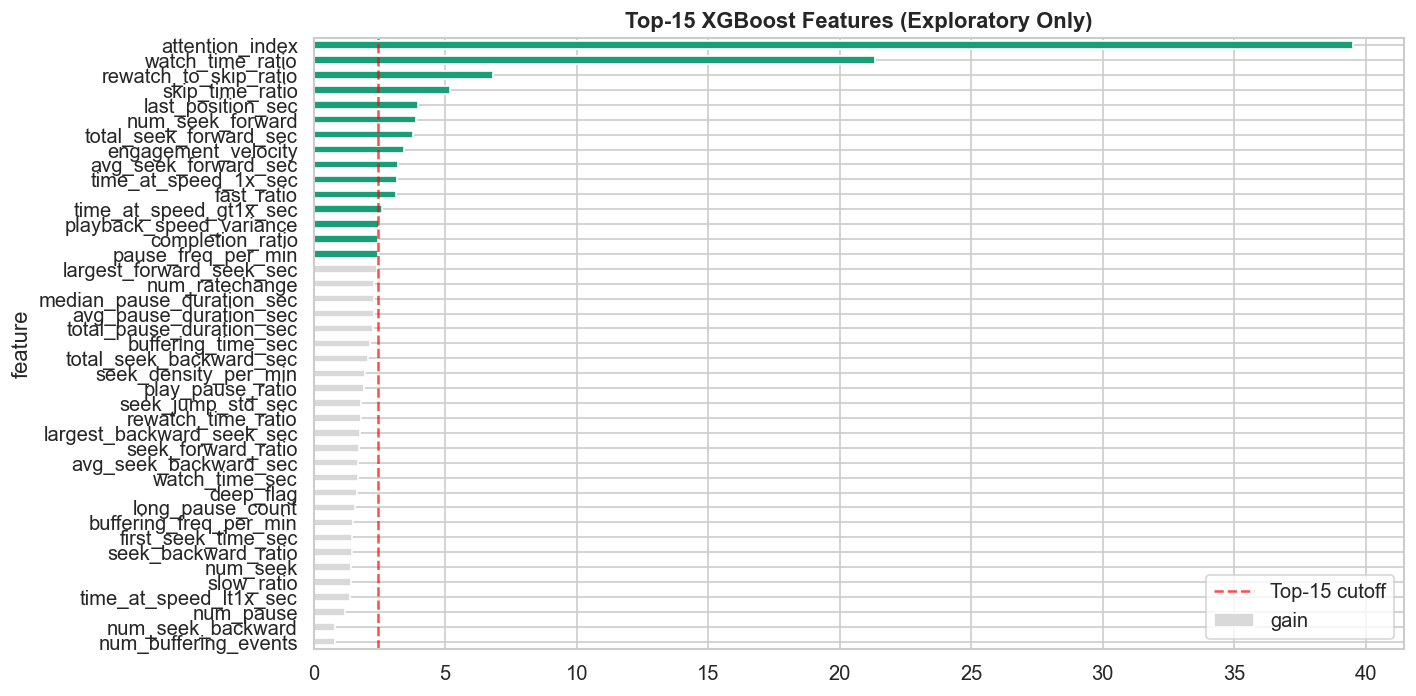

In [45]:
# Optional feature-ranking view to inspect strongest XGBoost signals.
TOP_N = min(15, len(xgb_imp_df))
selected_features = xgb_imp_df.head(TOP_N)["feature"].tolist()
print(f"Top {TOP_N} XGBoost features (analysis only; training still uses all {len(FEATURE_COLS)} features):")
for i, f in enumerate(selected_features, 1):
    print(f"  {i:2d}. {f}")

fig, ax = plt.subplots(figsize=(12, 6))
plot_df = xgb_imp_df.sort_values("gain", ascending=True)
colors = ["#1b9e77" if f in selected_features else "#d9d9d9" for f in plot_df["feature"]]
plot_df.plot(kind="barh", x="feature", y="gain", color=colors, ax=ax, legend=False)
if TOP_N > 0:
    cutoff = xgb_imp_df.iloc[TOP_N - 1]["gain"]
    ax.axvline(cutoff, color="red", ls="--", alpha=0.7, label=f"Top-{TOP_N} cutoff")
ax.set_title(f"Top-{TOP_N} XGBoost Features (Exploratory Only)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


---
## Step 10 - Save Models and Reports

Write artifacts and evaluation outputs for both models.


In [46]:
# Helpers for the XGBoost artifact/report export cell below.
# They are only needed when saving metadata and CV summaries.

def xgb_to_python_number(value):
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    return value

def save_xgb_cv_results(results: list[dict[str, object]], out_dir: Path) -> None:
    """Persist random-search trial summaries so tuning is auditable later."""
    rows = []
    for result in results:
        row = {
            "trial": int(result["trial"]),
            "mean_auc": float(result["mean_auc"]),
            "std_auc": float(result["std_auc"]),
            "best_round": int(result["best_round"]),
        }
        row.update({f"param_{key}": xgb_to_python_number(value) for key, value in result["params"].items()})
        rows.append(row)

    pd.DataFrame(rows).sort_values("mean_auc", ascending=False).to_csv(
        out_dir / "cv_results.csv",
        index=False,
    )


In [47]:
# Save two XGBoost models:
# - model.joblib: retrained on all labeled data for real inference
# - model_eval.joblib: the train/test evaluation model used for analysis
# XGBOOST: Production model (artifact format)
xgb_production_preprocessing = fit_numeric_preprocessing(clean_df[FEATURE_COLS])
X_all = transform_numeric_frame(clean_df[FEATURE_COLS], xgb_production_preprocessing)
y_all = clean_df[LABEL_COL].astype(int).values

dfull = xgb.DMatrix(X_all.values, label=y_all, feature_names=FEATURE_COLS)
xgb_prod = xgb.train(
    params=xgb_best["params"],
    dtrain=dfull,
    num_boost_round=int(xgb_best["best_round"]),
    verbose_eval=False,
)

joblib.dump(xgb_prod, os.path.join(XGBOOST_ARTIFACTS, "model.joblib"))
joblib.dump(xgb_model, os.path.join(XGBOOST_ARTIFACTS, "model_eval.joblib"))

with open(os.path.join(XGBOOST_ARTIFACTS, "feature_columns.json"), "w", encoding="utf-8") as f:
    json.dump(FEATURE_COLS, f, indent=2)

save_preprocessing_artifact(xgb_production_preprocessing, Path(XGBOOST_ARTIFACTS) / "preprocessing.json")
save_preprocessing_artifact(eval_preprocessing, Path(XGBOOST_ARTIFACTS) / "preprocessing_eval.json")

xgb_split_info = {
    "train_session_ids": train_session_ids,
    "test_session_ids": test_session_ids,
    "test_size": 0.2,
    "random_state": SEED,
    "group_col": GROUP_COL,
    "label_col": LABEL_COL,
    "train_rows": int(len(train_df)),
    "test_rows": int(len(test_df)),
}
with open(os.path.join(XGBOOST_ARTIFACTS, "split.json"), "w", encoding="utf-8") as f:
    json.dump(xgb_split_info, f, indent=2)

xgb_predictions_df.to_csv(os.path.join(XGBOOST_REPORT_DIR, "test_predictions.csv"), index=False)
xgb_predictions_df[xgb_predictions_df["error_type_0.85"] != "correct"].to_csv(
    os.path.join(XGBOOST_REPORT_DIR, "test_misclassifications.csv"), index=False
)
xgb_sweep.to_csv(os.path.join(XGBOOST_REPORT_DIR, "threshold_sweep.csv"), index=False)
if not xgb_imp_df.empty:
    xgb_imp_df.head(20).to_csv(os.path.join(XGBOOST_REPORT_DIR, "feature_importance_gain.csv"), index=False)
save_xgb_cv_results(xgb_best["all_results"], Path(XGBOOST_REPORT_DIR))

with open(os.path.join(XGBOOST_REPORT_DIR, "training_evals_result.json"), "w", encoding="utf-8") as f:
    json.dump(xgb_training_evals, f, indent=2)
with open(os.path.join(XGBOOST_REPORT_DIR, "metrics_test.json"), "w", encoding="utf-8") as f:
    json.dump(xgb_metrics, f, indent=2)

xgb_summary = {
    "dataset_rows_total": int(len(clean_df)),
    "dataset_users_total": int(clean_df[GROUP_COL].nunique()),
    "feature_count": int(len(FEATURE_COLS)),
    "train_rows": int(len(train_df)),
    "test_rows": int(len(test_df)),
    "train_users": int(train_df[GROUP_COL].nunique()),
    "test_users": int(test_df[GROUP_COL].nunique()),
    "best_params": {k: xgb_to_python_number(v) for k, v in xgb_best["params"].items()},
    "best_round": int(xgb_best["best_round"]),
    "metrics_test": xgb_metrics,
}
with open(os.path.join(XGBOOST_REPORT_DIR, "training_summary.json"), "w", encoding="utf-8") as f:
    json.dump(xgb_summary, f, indent=2)

xgb_top_trials = sorted(xgb_best["all_results"], key=lambda item: item["mean_auc"], reverse=True)[:10]
xgb_metadata = {
    "trained_at": datetime.now(timezone.utc).isoformat(),
    "model": "xgboost.Booster",
    "xgboost_version": xgb.__version__,
    "n_features": len(FEATURE_COLS),
    "feature_columns": FEATURE_COLS,
    "label_col": LABEL_COL,
    "group_col": GROUP_COL,
    "test_size": 0.2,
    "random_state": SEED,
    "engagement_threshold": ENGAGEMENT_THRESHOLD,
    "drop_cols": DROP_COLS,
    "best_params": {k: xgb_to_python_number(v) for k, v in xgb_best["params"].items()},
    "best_round": int(xgb_best["best_round"]),
    "metrics_test": xgb_metrics,
    "preprocessing": {
        "strategy": "median_imputation",
        "production_artifact": "preprocessing.json",
        "evaluation_artifact": "preprocessing_eval.json",
    },
    "models": {
        "production_model": "model.joblib",
        "evaluation_model": "model_eval.joblib",
    },
    "reports_dir": XGBOOST_REPORT_DIR,
    "top_cv_trials": [
        {
            "trial": int(item["trial"]),
            "mean_auc": round(float(item["mean_auc"]), 6),
            "std_auc": round(float(item["std_auc"]), 6),
            "best_round": int(item["best_round"]),
            "params": {k: xgb_to_python_number(v) for k, v in item["params"].items()},
        }
        for item in xgb_top_trials
    ],
    "dataset_summary": xgb_summary,
    "dataset_source": labeled_path,
}
with open(os.path.join(XGBOOST_ARTIFACTS, "metadata.json"), "w", encoding="utf-8") as f:
    json.dump(xgb_metadata, f, indent=2)

print(f"XGBoost production artifacts saved to: {XGBOOST_ARTIFACTS}")
print(f"XGBoost reports saved to: {XGBOOST_REPORT_DIR}")

XGBoost production artifacts saved to: e:\IIT\YEAR 05\SEMISTER 01\FYP\certifytube_ml_model\verification\engagement\xgboost\artifacts
XGBoost reports saved to: e:\IIT\YEAR 05\SEMISTER 01\FYP\certifytube_ml_model\reports\xgboost


In [48]:
# Helpers for the EBM artifact/report export cell below.
# They are only needed when writing training metadata and trial summaries.

def ebm_to_python_number(value):
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    return value

def save_ebm_cv_results(results: list[dict[str, object]], out_dir: Path) -> None:
    """Persist random-search trial summaries for later inspection."""
    rows = []
    for result in results:
        row = {
            "trial": int(result["trial"]),
            "mean_auc": float(result["mean_auc"]),
            "std_auc": float(result["std_auc"]),
        }
        row.update({f"param_{key}": ebm_to_python_number(value) for key, value in result["params"].items()})
        rows.append(row)

    pd.DataFrame(rows).sort_values("mean_auc", ascending=False).to_csv(
        out_dir / "cv_results.csv",
        index=False,
    )


In [49]:
# Save two EBM models with the same idea as XGBoost:
# production artifact on all data, plus the evaluation artifact for analysis.
# EBM: Production model (artifact format)
ebm_production_preprocessing = fit_numeric_preprocessing(clean_df[FEATURE_COLS])
X_all_ebm = transform_numeric_frame(clean_df[FEATURE_COLS], ebm_production_preprocessing)
y_all = clean_df[LABEL_COL].astype(int).values

ebm_prod = _build_ebm_model(FEATURE_COLS, ebm_best["params"])
ebm_prod.fit(X_all_ebm.values, y_all)

joblib.dump(ebm_prod, os.path.join(EBM_ARTIFACTS, "ebm_model.joblib"))
joblib.dump(ebm_model, os.path.join(EBM_ARTIFACTS, "ebm_model_eval.joblib"))

with open(os.path.join(EBM_ARTIFACTS, "ebm_feature_columns.json"), "w", encoding="utf-8") as f:
    json.dump(FEATURE_COLS, f, indent=2)

save_preprocessing_artifact(ebm_production_preprocessing, Path(EBM_ARTIFACTS) / "ebm_preprocessing.json")
save_preprocessing_artifact(eval_preprocessing, Path(EBM_ARTIFACTS) / "ebm_preprocessing_eval.json")

ebm_split_info = {
    "train_session_ids": train_session_ids,
    "test_session_ids": test_session_ids,
    "test_size": 0.2,
    "random_state": SEED,
    "group_col": GROUP_COL,
    "label_col": LABEL_COL,
    "train_rows": int(len(train_df)),
    "test_rows": int(len(test_df)),
}
with open(os.path.join(EBM_ARTIFACTS, "ebm_split.json"), "w", encoding="utf-8") as f:
    json.dump(ebm_split_info, f, indent=2)

ebm_predictions_df.to_csv(os.path.join(EBM_REPORT_DIR, "test_predictions.csv"), index=False)
ebm_predictions_df[ebm_predictions_df["error_type_0.85"] != "correct"].to_csv(
    os.path.join(EBM_REPORT_DIR, "test_misclassifications.csv"), index=False
)
ebm_sweep.to_csv(os.path.join(EBM_REPORT_DIR, "threshold_sweep.csv"), index=False)
if "ebm_imp_df" in globals() and not ebm_imp_df.empty:
    ebm_imp_df.head(20).to_csv(os.path.join(EBM_REPORT_DIR, "term_importances.csv"), index=False)
save_ebm_cv_results(ebm_best["all_results"], Path(EBM_REPORT_DIR))

with open(os.path.join(EBM_REPORT_DIR, "metrics_test.json"), "w", encoding="utf-8") as f:
    json.dump(ebm_metrics, f, indent=2)

ebm_summary = {
    "dataset_rows_total": int(len(clean_df)),
    "dataset_users_total": int(clean_df[GROUP_COL].nunique()),
    "feature_count": int(len(FEATURE_COLS)),
    "train_rows": int(len(train_df)),
    "test_rows": int(len(test_df)),
    "train_users": int(train_df[GROUP_COL].nunique()),
    "test_users": int(test_df[GROUP_COL].nunique()),
    "best_params": {k: ebm_to_python_number(v) for k, v in ebm_best["params"].items()},
    "metrics_test": ebm_metrics,
}
with open(os.path.join(EBM_REPORT_DIR, "training_summary.json"), "w", encoding="utf-8") as f:
    json.dump(ebm_summary, f, indent=2)

ebm_top_trials = sorted(ebm_best["all_results"], key=lambda item: item["mean_auc"], reverse=True)[:10]
ebm_metadata = {
    "trained_at": datetime.now(timezone.utc).isoformat(),
    "model": "ExplainableBoostingClassifier",
    "n_features": len(FEATURE_COLS),
    "feature_columns": FEATURE_COLS,
    "label_col": LABEL_COL,
    "group_col": GROUP_COL,
    "test_size": 0.2,
    "random_state": SEED,
    "engagement_threshold": ENGAGEMENT_THRESHOLD,
    "drop_cols": DROP_COLS,
    "best_params": {k: ebm_to_python_number(v) for k, v in ebm_best["params"].items()},
    "cv_best_auc": round(float(ebm_best["mean_auc"]), 6),
    "metrics_test": ebm_metrics,
    "preprocessing": {
        "strategy": "median_imputation",
        "production_artifact": "ebm_preprocessing.json",
        "evaluation_artifact": "ebm_preprocessing_eval.json",
    },
    "models": {
        "production_model": "ebm_model.joblib",
        "evaluation_model": "ebm_model_eval.joblib",
    },
    "reports_dir": EBM_REPORT_DIR,
    "top_cv_trials": [
        {
            "trial": int(item["trial"]),
            "mean_auc": round(float(item["mean_auc"]), 6),
            "std_auc": round(float(item["std_auc"]), 6),
            "params": {k: ebm_to_python_number(v) for k, v in item["params"].items()},
        }
        for item in ebm_top_trials
    ],
    "dataset_summary": ebm_summary,
    "n_terms": len(ebm_prod.term_names_),
    "term_names": list(ebm_prod.term_names_),
    "dataset_source": labeled_path,
}
with open(os.path.join(EBM_ARTIFACTS, "ebm_metadata.json"), "w", encoding="utf-8") as f:
    json.dump(ebm_metadata, f, indent=2)

print(f"EBM production artifacts saved to: {EBM_ARTIFACTS}")
print(f"EBM reports saved to: {EBM_REPORT_DIR}")

EBM production artifacts saved to: e:\IIT\YEAR 05\SEMISTER 01\FYP\certifytube_ml_model\verification\engagement\ebm\artifacts
EBM reports saved to: e:\IIT\YEAR 05\SEMISTER 01\FYP\certifytube_ml_model\reports\ebm


In [50]:
# Save combined model metrics for quick backend/reference use.
comparison_dir = Path(ENGAGEMENT_REPORT_DIR)
comparison_dir.mkdir(parents=True, exist_ok=True)

dual_metrics = {
    "xgboost": xgb_metrics,
    "ebm": ebm_metrics,
    "xgboost_cv_mean_auc": float(xgb_cv.mean()),
    "xgboost_cv_std_auc": float(xgb_cv.std()),
    "ebm_cv_mean_auc": float(ebm_cv.mean()),
    "ebm_cv_std_auc": float(ebm_cv.std()),
    "best_model": best_model_name,
    "train_rows": int(len(train_df)),
    "test_rows": int(len(test_df)),
    "train_users": int(train_df[GROUP_COL].nunique()),
    "test_users": int(test_df[GROUP_COL].nunique()),
    "user_overlap": int(len(set(train_df[GROUP_COL]) & set(test_df[GROUP_COL]))),
    "engagement_threshold": ENGAGEMENT_THRESHOLD,
    "dataset_source": labeled_path,
}
with open(comparison_dir / "dual_model_metrics.json", "w", encoding="utf-8") as f:
    json.dump(dual_metrics, f, indent=2)

print(f"Comparison summary saved to: {comparison_dir / 'dual_model_metrics.json'}")
print("Per-model artifacts were written to reports/xgboost, reports/ebm, and both artifact folders.")


Comparison summary saved to: e:\IIT\YEAR 05\SEMISTER 01\FYP\certifytube_ml_model\reports\engagement\dual_model_metrics.json
Per-model artifacts were written to reports/xgboost, reports/ebm, and both artifact folders.


---
## Training Run Summary

### Saved Model Artifacts
```
verification/engagement/xgboost/artifacts/
verification/engagement/ebm/artifacts/
```

### Saved Reports
```
reports/xgboost/
reports/ebm/
reports/engagement/dual_model_metrics.json
```

Both models output probability scores in [0, 1].
Any final pass/fail threshold can be applied by the backend.
